<a href="https://colab.research.google.com/github/Argcy213/Home-Credit-OLS-Regression-/blob/main/Home_Credit_%E8%B3%87%E9%87%91%E9%9C%80%E6%B1%82%E9%A0%90%E6%B8%AC%EF%BC%9A%E9%81%8B%E7%94%A8%E5%A4%9A%E8%A1%A8%E7%89%B9%E5%BE%B5%E5%B7%A5%E7%A8%8B%E8%88%87_OLS_%E8%BF%B4%E6%AD%B8%E5%84%AA%E5%8C%96%E6%8E%88%E4%BF%A1%E6%B1%BA%E7%AD%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project | 專案報告

---

# Home Credit 資金需求預測：運用多表特徵工程與 OLS 迴歸優化授信決策分析

---

### 📋 Student Information 學生資訊

> **Name 姓名**: 陳信允
>
> **Student ID 學號**: 411177063


# Content 目錄


1. Executive Summary 執行摘要
2. Data Architecture & Feature Engineering（資料架構與特徵工程）

目前的檔案中已經開始做 application_train、bureau 等多表合併（JOIN）與聚合（Groupby）。這部分非常重要，請詳細說明你是如何從過往信用紀錄中萃取出有價值的特徵（例如：平均信貸金額、逾期紀錄等）。

展現你運用 Pandas 和 NumPy 進行複雜資料清理、處理缺失值與異常值的硬實力。

3. Exploratory Data Analysis, EDA（探索性資料分析）

這是目前檔案缺少的環節。 在進入 OLS 線性迴歸前，必須先用視覺化說故事。

利用 Matplotlib 和 Seaborn 繪製高品質圖表。例如：不同職業/收入群體的貸款額度分佈（Boxplot / Violin plot）、特徵之間的相關性熱力圖（Correlation Heatmap）。

4. Modeling & Business Insights（模型建立與商業洞察）

除了呈現 OLS 模型的 RMSE、R-squared 等統計指標外，更重要的是解釋模型係數（Coefficients）。

商業洞察範例： 「模型結果顯示，過去在其他銀行的信用歷史活躍度（bureau_active_count）與本次貸款額度呈高度正相關。建議業務單位在審核高額貸款時，應將外部徵信數據的權重提高 XX%。」

---
# 執行摘要 Executive Summary
---

# 📌 研究動機 (Research Motivation)
>在無擔保消費型信貸市場中，金融機構面臨的核心風控挑戰不僅是評估「客戶是否會違約」，更在於精準決定「應該核准多少額度」。過度寬鬆的核貸會引發客戶過度負債與潛在的巨額呆帳風險，而過度保守的決策則會導致利息收益流失並降低市占率。因此，透過量化模型建立客觀的額度定價基準，是平衡風險控管與收益最大化的關鍵商業課題。

# 🎯 研究標的 (Research Target)
>本專案以國際消費金融公司 Home Credit 的真實營運資料為基礎，旨在建構一個以**「核貸金額 (AMT_CREDIT)」**為目標變數的預測模型。研究重點在於剝離單純的「商品價格」因素，透過整合客戶的靜態財務基本面與動態的內外部歷史信用足跡，探索真正驅動銀行核貸決策的底層核心變數。

# 📊 內容精簡分析 (Brief Content Analysis)
>透過深度的探索性資料分析 (EDA)，本專案淬鍊出以下關鍵洞察：
>- 財務分佈與階級特徵：財務數據呈現典型的嚴重右偏態分佈。社經地位指標（如高等學歷、公務員或大型企業員工）顯著提升了客戶的核貸天花板。
>- 行為足跡的信用背書：客戶在外部徵信機構的平均額度與內部歷史申請頻率，為靜態收入提供了強大的行為補充，證明多數申請人具備活躍的借貸軌跡。
>- 揭露統計陷阱：分析指出「商品價格」與「核貸金額」存在近乎完美的正相關 (r > 0.98)，若直接納入將引發嚴重的多元共線性問題，掩蓋真實的信用評估邏輯。

# 🛠️ 技術應用 (Technology Application Showcase)
>本專案採用 Python 數據科學工具生態系（Pandas, Scikit-learn, Statsmodels）構建端到端的量化分析管線。核心技術亮點包含：
>- 多表聚合與特徵工程：跨資料表 (Bureau, Previous Application) 萃取並聚合歷史行為特徵。
>- 穩健的極端值處理：針對極度右偏的財務數據，捨棄 Z-score，採用抵抗力更強的 IQR (1.5倍) 策略進行離群值識別與截斷。
>- 雙對數迴歸模型 (Log-Log Model)：為解決線性模型面臨的異方差性 (Heteroscedasticity) 痛點，實作雙對數轉換穩定矩陣運算，有效收斂預測誤差。

# 📈 概略分析前預測結果 (Preliminary Predictive Results)
>在刻意排除高共線性特徵的嚴格條件下，專案建立的多元線性迴歸基準模型 (OLS Baseline) 仍能解釋約 60% (R² ≈ 0.58) 的核貸額度變異。
經殘差分析與對數優化後，平均絕對誤差 (MAE) 獲得顯著收斂，證明模型在一般受薪客群的預測上具備高度穩定性。然而，針對少數極端高淨值客戶產生的巨額預測誤差 (RMSE 居高)，進一步印證了信貸決策的非線性本質，為後續導入樹狀機器學習演算法 (如 LightGBM) 或實施客群分層風控 (Risk Segmentation) 提供了明確的升級藍圖。

---
## **0.** Environment Setup 環境設定
---

In [ ]:
# ============================================================
# Package Installation 安裝套件
# ============================================================
!pip install -q gdown statsmodels

print("✅ Packages installed successfully!")
print("✅ 套件安裝成功！")

✅ Packages installed successfully!
✅ 套件安裝成功！


### Chinese Font Setup 中文字體設定
Run the following cell to enable Chinese characters in your charts.

請執行以下儲存格以啟用圖表中的中文顯示。


In [ ]:
# ============================================================
# Chinese Font Setup 中文字體設定
# ============================================================
!wget -q -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib
import matplotlib.pyplot as plt

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')
plt.rcParams['axes.unicode_minus'] = False

print("✅ Chinese font configured successfully!")
print("✅ 中文字體設定成功！")


✅ Chinese font configured successfully!
✅ 中文字體設定成功！


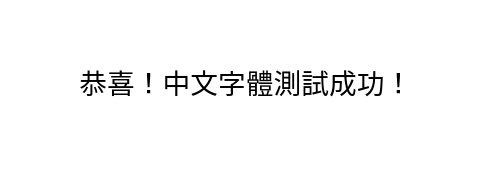

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import matplotlib

# 1. 下載字體 (如果還沒下載的話)
font_path = "TaipeiSansTCBeta-Regular.ttf"
if not os.path.exists(font_path):
    !wget -q -O {font_path} https://raw.githubusercontent.com/An-Jun/TaipeiSansTCBeta/master/TaipeiSansTCBeta-Regular.ttf

# 2. 清除 matplotlib 的暫存 (有時候快取會導致新字體讀不到)
# 這裡我們直接將字體強制塞進系統的 FontManager
fm.fontManager.addfont(font_path)

# 3. 強制指定字體家族名稱 (必須與字體檔內部的真實名稱完全一致)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 4. 畫一張小圖直接測試！
plt.figure(figsize=(6, 2))
plt.text(0.5, 0.5, ' 恭喜！中文字體測試成功！', fontsize=20, ha='center', va='center')
plt.axis('off') # 隱藏坐標軸
plt.show()

### Import Libraries 匯入函式庫
Import all libraries you will need for this exam. A starter template is provided below — feel free to add more as needed.

匯入本次考試所需的所有函式庫。以下提供起始模板，你可以根據需要自行增加。


In [ ]:
# ============================================================
# Library Imports 函式庫匯入
# ============================================================

# Data manipulation 資料處理
import numpy as np
import pandas as pd
import os

# Visualization 視覺化
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 機器學習
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Statistics 統計
from scipy import stats
import statsmodels.api as sm

# Suppress warnings 抑制警告
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility 設定隨機種子以確保可重現性
np.random.seed(42)

# Display settings 顯示設定
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("✅ All libraries imported successfully!")
print("✅ 所有函式庫匯入成功！")


✅ All libraries imported successfully!
✅ 所有函式庫匯入成功！


---
##  **1.** Data Loading & Multi-table JOIN 資料載入與多表合併
---


### **1.1** Load Dataset 載入資料集

In [ ]:
# @title
# 1. 確保 gdown 是最新版本 (避免下載資料夾的 Bug)
!pip install --upgrade gdown

# 2. 重新執行下載指令 (拿掉 -q，讓它顯示下載進度)
!gdown --folder https://drive.google.com/drive/folders/1HZvSZG4bspAu5ANpiNiZk2tojrdqzxHk

# 3. 下載完畢後，再次列出目錄確認
!ls -l

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Retrieving folder contents
Processing file 1fazDHiHA3VJO4AZ8sURYCDcJ9prje7PN application_train.csv
Processing file 1pPwbSGp8ITSc16Xjwnk5Ku7oKQtLeqV0 bureau.csv
Processing file 16nRN0BEyEng78pJeA87eQ47lqvD2ULgm previous_application.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1fazDHiHA3VJO4AZ8sURYCDcJ9prje7PN
From (redirected): https://drive.google.com/uc?id=1fazDHiHA3VJO4AZ8sURYCDcJ9prje7PN&confirm=t&uuid=c7454e1b-c6f7-43ad-8980-a86db36ebc50
To: /content/home_credit_default_risk/application_train.csv
100% 166M/166M [00:04<00:00, 37.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1pPwbSGp8ITSc16Xjwnk5Ku7oKQtLeqV0
From (redirected): https://drive.google.com/uc?id=1pPwbSGp8ITSc16Xjwnk5Ku7oKQtLeqV0

### **1.2** Initial Data Exploration 初步資料探索

In [ ]:

import pandas as pd
from IPython.display import display
import os

# 定義目標檔案
target_files = ['application_train.csv', 'bureau.csv', 'previous_application.csv']
file_paths = {}

# 1. 自動尋找檔案路徑
for root, dirs, files in os.walk('.'):
    for file in files:
        if file in target_files:
            file_paths[file] = os.path.join(root, file)

# === 補齊缺少的需求：定義每張資料表的用途說明 ===
table_descriptions = {
    'application_train.csv': "這是主要的訓練資料集，包含申請人的基本靜態資訊（如性別、收入）與目標變數 TARGET（是否違約）。",
    'bureau.csv': "這是外部徵信局提供的資料，記錄了客戶在其他金融機構的過去信用歷史與貸款狀態。",
    'previous_application.csv': "記錄了客戶過去在 Home Credit 本公司的歷史貸款申請細節與最終核貸結果。"
}

datasets = {}

# 2. 檢查檔案並輸出結果
if len(file_paths) == len(target_files):
    for file_name in target_files:
        actual_path = file_paths[file_name]

        # 讀取 CSV 檔案
        df = pd.read_csv(actual_path)
        datasets[file_name] = df

        # 取得維度 (Shape)
        rows, cols = df.shape

        # 取得包含資料型態的欄位名稱 (Data types)
        col_info = [f"{col} ({dtype})" for col, dtype in zip(df.columns, df.dtypes)]
        col_names = ", ".join(col_info)

        # --- 開始輸出作業要求的所有資訊 ---
        print(f"Dataset loaded: {file_name} {rows}*{cols}")

        # 輸出 1-2 句話的用途說明 (Purpose)
        print(f"📌 Table Purpose: {table_descriptions[file_name]}")

        # 輸出欄位與型態
        print(f"Columns: {{{col_names}}} .")

        # 顯示前 5 列資料 (First 5 rows)
        display(df.head())

        print("=" * 80 + "\n")

    print("✅ 已成功下載、載入需求檔案，並完成所有指定的資料探索任務！")

else:
    found_files = list(file_paths.keys())
    missing_files = set(target_files) - set(found_files)
    print(f"⚠️ 找不到部分檔案: {missing_files}，請確認是否下載成功。")

Dataset loaded: application_train.csv 307511*122
📌 Table Purpose: 這是主要的訓練資料集，包含申請人的基本靜態資訊（如性別、收入）與目標變數 TARGET（是否違約）。
Columns: {SK_ID_CURR (int64), TARGET (int64), NAME_CONTRACT_TYPE (object), CODE_GENDER (object), FLAG_OWN_CAR (object), FLAG_OWN_REALTY (object), CNT_CHILDREN (int64), AMT_INCOME_TOTAL (float64), AMT_CREDIT (float64), AMT_ANNUITY (float64), AMT_GOODS_PRICE (float64), NAME_TYPE_SUITE (object), NAME_INCOME_TYPE (object), NAME_EDUCATION_TYPE (object), NAME_FAMILY_STATUS (object), NAME_HOUSING_TYPE (object), REGION_POPULATION_RELATIVE (float64), DAYS_BIRTH (int64), DAYS_EMPLOYED (int64), DAYS_REGISTRATION (float64), DAYS_ID_PUBLISH (int64), OWN_CAR_AGE (float64), FLAG_MOBIL (int64), FLAG_EMP_PHONE (int64), FLAG_WORK_PHONE (int64), FLAG_CONT_MOBILE (int64), FLAG_PHONE (int64), FLAG_EMAIL (int64), OCCUPATION_TYPE (object), CNT_FAM_MEMBERS (float64), REGION_RATING_CLIENT (int64), REGION_RATING_CLIENT_W_CITY (int64), WEEKDAY_APPR_PROCESS_START (object), HOUR_APPR_PROCESS_START (

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0


Dataset loaded: bureau.csv 1716428*17
📌 Table Purpose: 這是外部徵信局提供的資料，記錄了客戶在其他金融機構的過去信用歷史與貸款狀態。
Columns: {SK_ID_CURR (int64), SK_ID_BUREAU (int64), CREDIT_ACTIVE (object), CREDIT_CURRENCY (object), DAYS_CREDIT (int64), CREDIT_DAY_OVERDUE (int64), DAYS_CREDIT_ENDDATE (float64), DAYS_ENDDATE_FACT (float64), AMT_CREDIT_MAX_OVERDUE (float64), CNT_CREDIT_PROLONG (int64), AMT_CREDIT_SUM (float64), AMT_CREDIT_SUM_DEBT (float64), AMT_CREDIT_SUM_LIMIT (float64), AMT_CREDIT_SUM_OVERDUE (float64), CREDIT_TYPE (object), DAYS_CREDIT_UPDATE (int64), AMT_ANNUITY (float64)} .


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.00,-153.00,NaN,0,"91,323.00",0.00,NaN,0.00,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,"1,075.00",NaN,NaN,0,"225,000.00","171,342.00",NaN,0.00,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.00,NaN,NaN,0,"464,323.50",NaN,NaN,0.00,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,"90,000.00",NaN,NaN,0.00,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,"1,197.00",NaN,"77,674.50",0,"2,700,000.00",NaN,NaN,0.00,Consumer credit,-21,NaN



Dataset loaded: previous_application.csv 1670214*37
📌 Table Purpose: 記錄了客戶過去在 Home Credit 本公司的歷史貸款申請細節與最終核貸結果。
Columns: {SK_ID_PREV (int64), SK_ID_CURR (int64), NAME_CONTRACT_TYPE (object), AMT_ANNUITY (float64), AMT_APPLICATION (float64), AMT_CREDIT (float64), AMT_DOWN_PAYMENT (float64), AMT_GOODS_PRICE (float64), WEEKDAY_APPR_PROCESS_START (object), HOUR_APPR_PROCESS_START (int64), FLAG_LAST_APPL_PER_CONTRACT (object), NFLAG_LAST_APPL_IN_DAY (int64), RATE_DOWN_PAYMENT (float64), RATE_INTEREST_PRIMARY (float64), RATE_INTEREST_PRIVILEGED (float64), NAME_CASH_LOAN_PURPOSE (object), NAME_CONTRACT_STATUS (object), DAYS_DECISION (int64), NAME_PAYMENT_TYPE (object), CODE_REJECT_REASON (object), NAME_TYPE_SUITE (object), NAME_CLIENT_TYPE (object), NAME_GOODS_CATEGORY (object), NAME_PORTFOLIO (object), NAME_PRODUCT_TYPE (object), CHANNEL_TYPE (object), SELLERPLACE_AREA (int64), NAME_SELLER_INDUSTRY (object), CNT_PAYMENT (float64), NAME_YIELD_GROUP (object), PRODUCT_COMBINATION (object), DAYS

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,"1,730.43","17,145.00","17,145.00",0.00,"17,145.00",SATURDAY,15,Y,1,0.00,0.18,0.87,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.00,middle,POS mobile with interest,"365,243.00",-42.00,300.00,-42.00,-37.00,0.00
1,2802425,108129,Cash loans,"25,188.62","607,500.00","679,671.00",NaN,"607,500.00",THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.00,low_action,Cash X-Sell: low,"365,243.00",-134.00,916.00,"365,243.00","365,243.00",1.00
2,2523466,122040,Cash loans,"15,060.74","112,500.00","136,444.50",NaN,"112,500.00",TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.00,high,Cash X-Sell: high,"365,243.00",-271.00,59.00,"365,243.00","365,243.00",1.00
3,2819243,176158,Cash loans,"47,041.33","450,000.00","470,790.00",NaN,"450,000.00",MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.00,middle,Cash X-Sell: middle,"365,243.00",-482.00,-152.00,-182.00,-177.00,1.00
4,1784265,202054,Cash loans,"31,924.40","337,500.00","404,055.00",NaN,"337,500.00",THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.00,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN



✅ 已成功下載、載入需求檔案，並完成所有指定的資料探索任務！


✏️ **Explanation 說明：**

> (Double-click this cell to edit 雙擊此儲存格進行編輯)
>
> - `application_train`: 這是主要的訓練資料集，包含申請人的基本靜態資訊（如性別、收入）與目標變數 TARGET（是否違約）。
> - `bureau`: 這是外部徵信局提供的資料，記錄了客戶在其他金融機構的過去信用歷史與貸款狀態。
> - `previous_application`: 記錄了客戶過去在 Home Credit 本公司的歷史貸款申請細節與最終核貸結果。


### **1.3** Aggregate Bureau Data 聚合 bureau 資料

Using `bureau.csv`, perform a **groupby** aggregation by `SK_ID_CURR` (Client ID) to calculate the following features:

使用 bureau.csv，以 SK_ID_CURR（客戶 ID）為單位進行 groupby 聚合，計算以下特徵：

| Feature 特徵名稱 | Calculation 計算方式 |
|:---|:---|
| `bureau_count` | Count of bureau records 信用局紀錄數量 |
| `bureau_avg_credit` | Mean of `AMT_CREDIT_SUM` 平均信貸金額 |
| `bureau_max_overdue` | Max of `CREDIT_DAY_OVERDUE` 最大逾期天數 |
| `bureau_active_count` | Count where `CREDIT_ACTIVE == 'Active'` 目前仍活躍的信貸數量 |


Bureau Aggregated Features (Top 5 Rows) / 信用局聚合特徵 (前 5 列)


,SK_ID_CURR,bureau_count,bureau_avg_credit,bureau_max_overdue,bureau_active_count
0,100001,7,"207,623.57",0,3
1,100002,8,"108,131.95",0,2
2,100003,4,"254,350.12",0,1
3,100004,2,"94,518.90",0,0
4,100005,3,"219,042.00",0,2



[Info] Aggregated DataFrame Shape / 聚合後資料維度: (305811, 5)


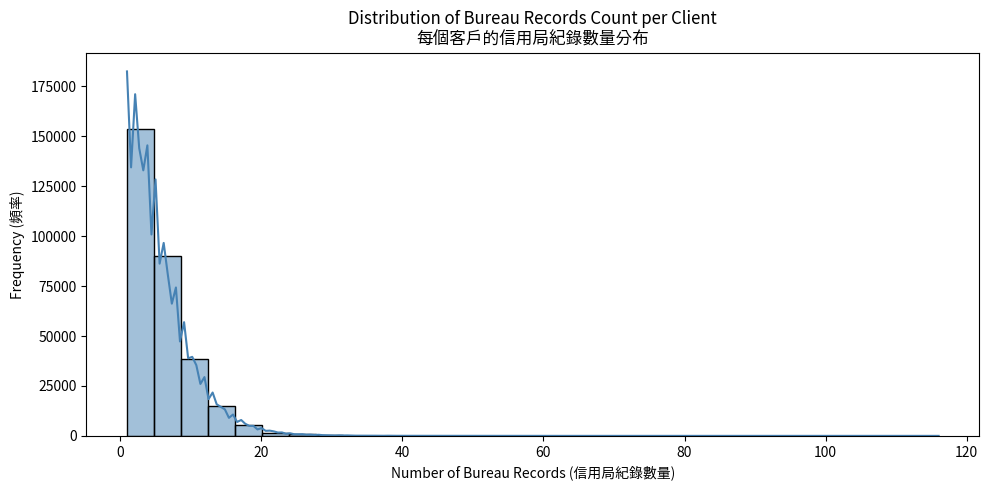

In [ ]:
# Tool Type: Data Manipulation & Feature Engineering (pandas) / Visualization (matplotlib, seaborn)
# 工具類型：資料操作與特徵工程 (pandas) / 資料視覺化 (matplotlib, seaborn)

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 🛑 修正關鍵：從 datasets 字典中明確取出 bureau.csv，並指派給獨立變數
# 如果你前面沒有存 datasets 字典，也可以改成：bureau_df = pd.read_csv('bureau.csv')
# =====================================================================
bureau_df = datasets['bureau.csv'].copy()

# Step 1: Data Preprocessing for Conditional Aggregation
# 步驟 1：建立條件判斷欄位，以利後續的條件聚合計算
# 使用 bureau_df 取代原本錯誤的 df
bureau_df['is_active_credit'] = (bureau_df['CREDIT_ACTIVE'] == 'Active').astype(int)

# Step 2: Groupby Aggregation
# 步驟 2：執行 groupby 聚合計算
bureau_aggregated = bureau_df.groupby('SK_ID_CURR').agg(
    bureau_count=('SK_ID_CURR', 'count'),                      # Count of bureau records 信用局紀錄數量
    bureau_avg_credit=('AMT_CREDIT_SUM', 'mean'),              # Mean of AMT_CREDIT_SUM 平均信貸金額
    bureau_max_overdue=('CREDIT_DAY_OVERDUE', 'max'),          # Max of CREDIT_DAY_OVERDUE 最大逾期天數
    bureau_active_count=('is_active_credit', 'sum')            # Count where CREDIT_ACTIVE == 'Active' 活躍信貸數量
).reset_index()

# Step 3: Print clearly formatted results
# 步驟 3：以清晰的格式列印出計算結果
print("=" * 70)
print("Bureau Aggregated Features (Top 5 Rows) / 信用局聚合特徵 (前 5 列)")
print("=" * 70)
display(bureau_aggregated.head())
print(f"\n[Info] Aggregated DataFrame Shape / 聚合後資料維度: {bureau_aggregated.shape}")
print("=" * 70)

# Step 4: Data Visualization
# 步驟 4：資料視覺化 (展示新特徵分布情況)
plt.figure(figsize=(10, 5))

# Plotting the distribution of bureau counts per client
# 繪製每個客戶信用局紀錄數量的分布圖
sns.histplot(data=bureau_aggregated, x='bureau_count', bins=30, kde=True, color='steelblue')
plt.title('Distribution of Bureau Records Count per Client\n每個客戶的信用局紀錄數量分布')
plt.xlabel('Number of Bureau Records (信用局紀錄數量)')
plt.ylabel('Frequency (頻率)')

# Apply tight_layout as requested
# 套用要求的 tight_layout()
plt.tight_layout()
plt.show()

### **1.4** Aggregate Previous Application Data 聚合歷史申請資料

Using `previous_application.csv`, perform a **groupby** aggregation by `SK_ID_CURR` to calculate:

使用 previous_application.csv，以 SK_ID_CURR 為單位進行 groupby 聚合，計算以下特徵：

| Feature 特徵名稱 | Calculation 計算方式 |
|:---|:---|
| `prev_app_count` | Count of previous applications 歷史申請次數 |
| `prev_avg_amount` | Mean of `AMT_APPLICATION` 平均申請金額 |
| `prev_approved_ratio` | Proportion where `NAME_CONTRACT_STATUS == 'Approved'` 核准比例 |
| `prev_avg_credit` | Mean of `AMT_CREDIT` 平均核准金額 |


Previous Application Aggregated Features (Top 5 Rows) / 歷史申請聚合特徵 (前 5 列)


,SK_ID_CURR,prev_app_count,prev_avg_amount,prev_approved_ratio,prev_avg_credit
0,100001,1,"24,835.50",1.00,"23,787.00"
1,100002,1,"179,055.00",1.00,"179,055.00"
2,100003,3,"435,436.50",1.00,"484,191.00"
3,100004,1,"24,282.00",1.00,"20,106.00"
4,100005,2,"22,308.75",0.50,"20,076.75"



[Info] Aggregated DataFrame Shape / 聚合後資料維度: (338857, 5)


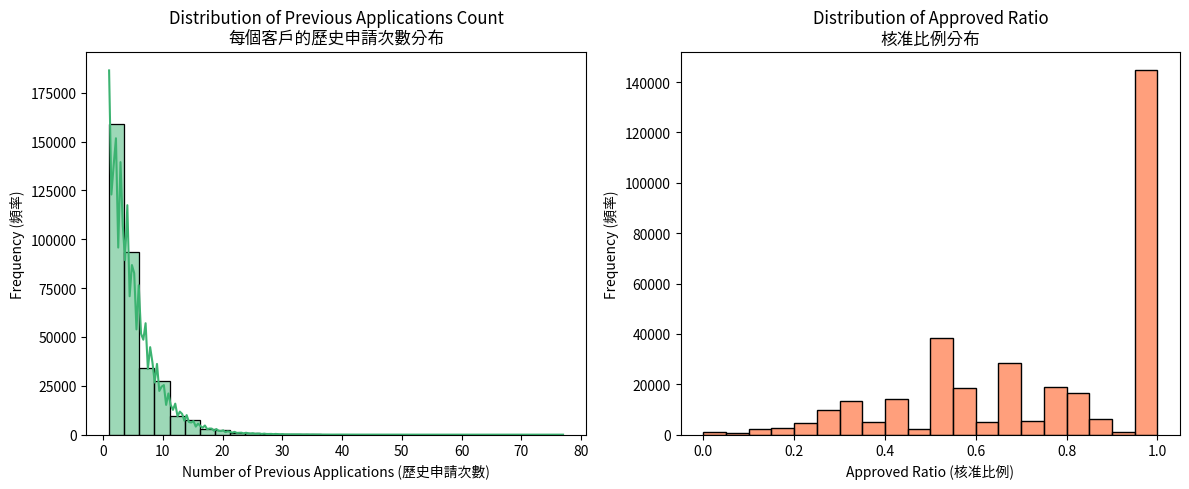

In [ ]:
# Tool Type: Data Manipulation & Feature Engineering (pandas) / Visualization (matplotlib, seaborn)
# 工具類型：資料操作與特徵工程 (pandas) / 資料視覺化 (matplotlib, seaborn)

import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 確保我們使用的是正確的資料表：previous_application.csv
# =====================================================================
prev_df = datasets['previous_application.csv'].copy()

# Step 1: Data Preprocessing for Conditional Aggregation
# 步驟 1：建立條件判斷欄位 (計算核准比例)
# Create a binary column: 1 if 'Approved', 0 otherwise
# 建立二元特徵：如果是 'Approved' 設為 1，否則為 0
prev_df['is_approved'] = (prev_df['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)

# Step 2: Groupby Aggregation
# 步驟 2：執行 groupby 聚合計算
prev_aggregated = prev_df.groupby('SK_ID_CURR').agg(
    prev_app_count=('SK_ID_CURR', 'count'),                  # Count of previous applications 歷史申請次數
    prev_avg_amount=('AMT_APPLICATION', 'mean'),             # Mean of AMT_APPLICATION 平均申請金額
    prev_approved_ratio=('is_approved', 'mean'),             # Proportion of 'Approved' 核准比例 (0與1的平均值即為比例)
    prev_avg_credit=('AMT_CREDIT', 'mean')                   # Mean of AMT_CREDIT 平均核准金額
).reset_index()

# Step 3: Print clearly formatted results
# 步驟 3：以清晰的格式列印出計算結果
print("=" * 75)
print("Previous Application Aggregated Features (Top 5 Rows) / 歷史申請聚合特徵 (前 5 列)")
print("=" * 75)
display(prev_aggregated.head())
print(f"\n[Info] Aggregated DataFrame Shape / 聚合後資料維度: {prev_aggregated.shape}")
print("=" * 75)

# Step 4: Data Visualization
# 步驟 4：資料視覺化 (展示新特徵分布情況)
# 這裡我們畫兩張圖並排：一張看申請次數，一張看核准比例
plt.figure(figsize=(12, 5))

# Plot 1: Distribution of previous application counts
# 圖 1：繪製每個客戶歷史申請次數的分布圖
plt.subplot(1, 2, 1)
sns.histplot(data=prev_aggregated, x='prev_app_count', bins=30, kde=True, color='mediumseagreen')
plt.title('Distribution of Previous Applications Count\n每個客戶的歷史申請次數分布')
plt.xlabel('Number of Previous Applications (歷史申請次數)')
plt.ylabel('Frequency (頻率)')

# Plot 2: Distribution of approved ratio
# 圖 2：繪製核准比例的分布圖
plt.subplot(1, 2, 2)
sns.histplot(data=prev_aggregated, x='prev_approved_ratio', bins=20, color='coral')
plt.title('Distribution of Approved Ratio\n核准比例分布')
plt.xlabel('Approved Ratio (核准比例)')
plt.ylabel('Frequency (頻率)')

# Apply tight_layout as requested
# 套用要求的 tight_layout()
plt.tight_layout()
plt.show()

### **1.5** Merge Tables 合併資料表
Use **LEFT JOIN** (`pd.merge`, `how='left'`) to merge the aggregated bureau and previous application data back to `application_train`, using `SK_ID_CURR` as the key. Display the **shape** and **first 5 rows** of the merged table.


In [ ]:
# Tool Type: Data Manipulation (pandas)
# 工具類型：資料操作 (pandas)

# 確保我們取得原始的主訓練資料表
app_train = datasets['application_train.csv'].copy()

# Step 1: Merge bureau aggregated features into the main table
# 步驟 1：將信用局聚合特徵 (bureau_aggregated) 使用 LEFT JOIN 合併回主表
app_train_merged = pd.merge(app_train, bureau_aggregated, on='SK_ID_CURR', how='left')

# Step 2: Merge previous application aggregated features into the main table
# 步驟 2：將歷史申請聚合特徵 (prev_aggregated) 使用 LEFT JOIN 合併回主表
app_train_merged = pd.merge(app_train_merged, prev_aggregated, on='SK_ID_CURR', how='left')

# Step 3: Print clearly formatted results
# 步驟 3：以清晰的格式列印出形狀與前五列資料
print("=" * 80)
print(f"✅ Merged DataFrame Shape / 合併後資料維度: {app_train_merged.shape}")
print("=" * 80)
print("Merged DataFrame (First 5 Rows) / 合併後資料表 (前 5 列):")

# 顯示前 5 筆資料 (觀察最後面新增的欄位)
display(app_train_merged.head())

✅ Merged DataFrame Shape / 合併後資料維度: (307511, 130)
Merged DataFrame (First 5 Rows) / 合併後資料表 (前 5 列):


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,bureau_count,bureau_avg_credit,bureau_max_overdue,bureau_active_count,prev_app_count,prev_avg_amount,prev_approved_ratio,prev_avg_credit
0,100002,1,Cash loans,M,N,Y,0,"202,500.00","406,597.50","24,700.50","351,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,"-3,648.00",-2120,NaN,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.63,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,0.03,0.04,0.97,0.62,0.01,0.00,0.07,0.08,0.12,0.04,0.02,0.02,0.00,0.00,reg oper account,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,"-1,134.00",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00,8.00,"108,131.95",0.00,2.00,1.00,"179,055.00",1.00,"179,055.00"
1,100003,0,Cash loans,F,N,N,0,"270,000.00","1,293,502.50","35,698.50","1,129,500.00",Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,"-1,186.00",-291,NaN,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.05,0.00,0.01,0.09,0.05,0.99,0.80,0.05,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.00,0.10,0.05,0.99,0.80,0.06,0.08,0.03,0.29,0.33,0.01,0.08,0.06,0.00,0.01,reg oper account,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,4.00,"254,350.12",0.00,1.00,3.00,"435,436.50",1.00,"484,191.00"
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.00","135,000.00","6,750.00","135,000.00",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,"-4,260.00",-2531,26.00,1,1,1,1,1,0,Laborers,1.00,2,2,

##**1.** 小結總結
本階段讀取核心申請表，並透過 SK_ID_CURR 鍵值，將外部徵信局 (Bureau) 與內部歷史申請 (Previous Application) 資料進行特徵聚合與 Left Join。

---
##**2.** 資料清理與特徵工程 (Data Preprocessing & Feature Engineering)
---


### **2.1** Missing Value Distribution 遺失值分布分析

For the merged dataset:

針對合併後的資料表，我們必將執行以下來計算遺失值的分布

1. Calculate the **count and percentage** of missing values for each column 計算每個欄位的遺失值數量與比例
2. Plot a **bar chart** of missing value percentages (only columns with missing values, sorted from high to low) 繪製遺失值比例的條形圖（只顯示有遺失值的欄位，由高到低排序）
3. **Annotate** which columns have missing rates above 50% 標註哪些欄位遺失比例超過 50%


Missing Values Summary (Top 10) / 遺失值統計表 (前 10 名)


,Missing_Count,Missing_Percent
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_AVG,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_MODE,210199,68.35
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35



🚨 Columns with > 50% missing values (41 columns):
遺失比例超過 50% 的欄位 (共 41 個):
['COMMONAREA_MEDI', 'COMMONAREA_MODE', 'COMMONAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MODE', 'LANDAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'EXT_SOURCE_1', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_AVG', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'WALLSMATERIAL_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_MEDI', 'ENTRANCES_AVG', 'LIVINGAREA_MODE', 'LIVINGAREA_MEDI', 'LIVINGAREA_AVG', 'HOUSETYPE_MODE']


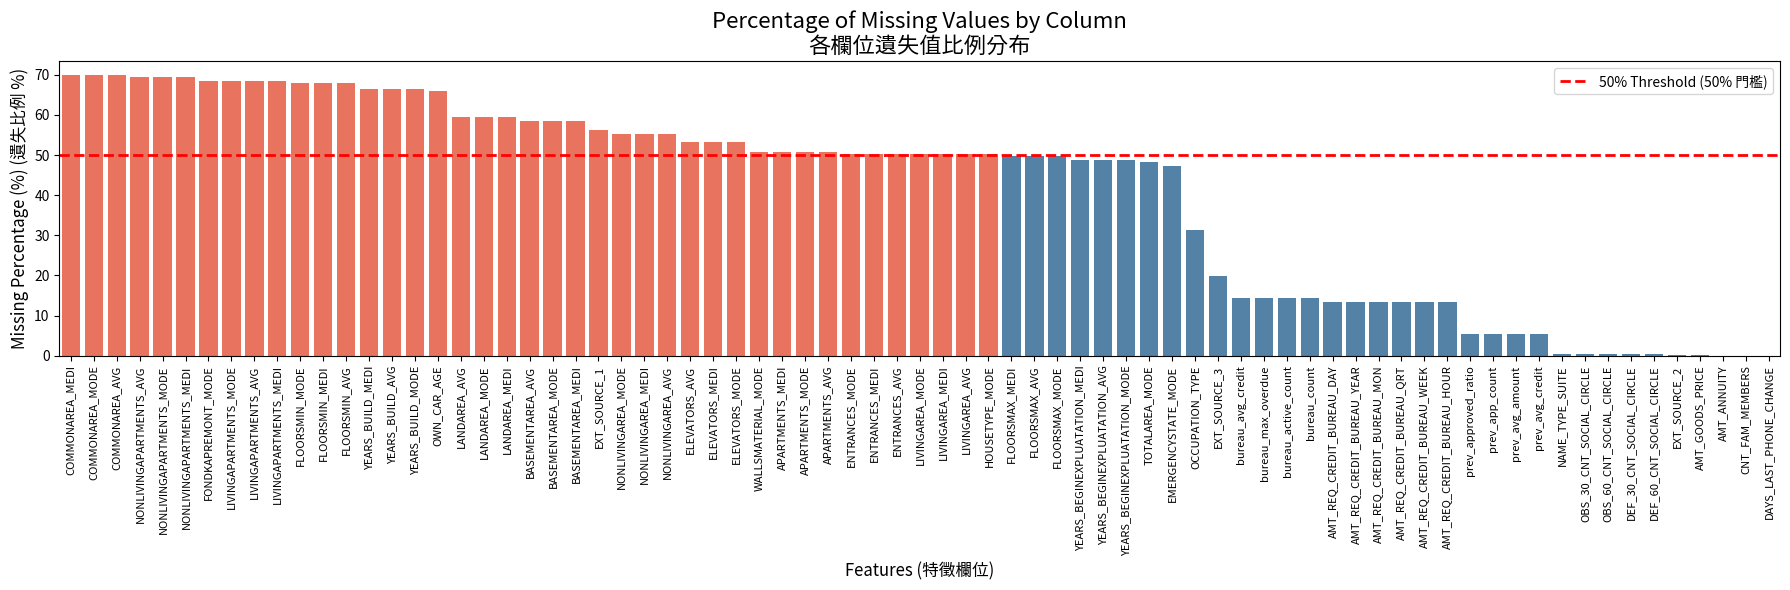

In [ ]:
# Tool Type: Data Exploration (pandas) / Visualization (matplotlib, seaborn)
# 工具類型：資料探索 (pandas) / 資料視覺化 (matplotlib, seaborn)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate missing value count and percentage for each column
# 步驟 1：計算每個欄位的遺失值數量與比例
missing_counts = app_train_merged.isnull().sum()
missing_percent = (app_train_merged.isnull().mean() * 100)

# Create a DataFrame to store the results
# 建立一個 DataFrame 來儲存結果
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percent': missing_percent
})

# Filter out columns with 0 missing values and sort by percentage (High to Low)
# 過濾掉沒有遺失值的欄位，並依照遺失比例由高到低排序
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent', ascending=False)

# Step 2: Print clearly formatted numerical results (Top 10)
# 步驟 2：列印出計算結果 (為了版面簡潔，這裡顯示遺失率最高的前 10 名)
print("=" * 70)
print("Missing Values Summary (Top 10) / 遺失值統計表 (前 10 名)")
print("=" * 70)
display(missing_df.head(10))

# Step 3: Identify and annotate columns with > 50% missing rate
# 步驟 3：找出並標註遺失比例超過 50% 的欄位
cols_above_50 = missing_df[missing_df['Missing_Percent'] > 50].index.tolist()
print("\n" + "=" * 70)
print(f"🚨 Columns with > 50% missing values ({len(cols_above_50)} columns):")
print(f"遺失比例超過 50% 的欄位 (共 {len(cols_above_50)} 個):")
print(cols_above_50)
print("=" * 70)

# Step 4: Data Visualization (Bar Chart)
# 步驟 4：資料視覺化 (繪製遺失值比例條形圖)
plt.figure(figsize=(18, 6)) # Make figure wide to accommodate many column names

# Create a custom color palette: Red for > 50%, Steelblue for <= 50%
# 建立自訂調色盤：大於 50% 為紅色，小於等於 50% 為鐵藍色
colors = ['tomato' if pct > 50 else 'steelblue' for pct in missing_df['Missing_Percent']]

# Plot the bar chart
# 繪製長條圖
sns.barplot(x=missing_df.index, y='Missing_Percent', data=missing_df, palette=colors)

# Add a horizontal dashed line at 50%
# 加上 50% 的水平虛線輔助線
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% Threshold (50% 門檻)')

# Formatting the plot
# 圖表格式設定
plt.title('Percentage of Missing Values by Column\n各欄位遺失值比例分布', fontsize=16)
plt.xlabel('Features (特徵欄位)', fontsize=12)
plt.ylabel('Missing Percentage (%) (遺失比例 %)', fontsize=12)

# Rotate x-axis labels by 90 degrees so they don't overlap
# 將 X 軸的標籤旋轉 90 度避免字體重疊
plt.xticks(rotation=90, fontsize=8)
plt.legend()

# Apply tight_layout as requested
# 套用要求的 tight_layout()
plt.tight_layout()
plt.show()

### **2.2** Missing Value Strategy 遺失值處理策略



**1. Missing > 50%**:
>- 如何處理 (How to handle)： * 主要動作： 直接刪除 (Drop) 這些特徵欄位。
>   - 進階考量 (特徵工程)： 在刪除原欄位之前，可以建立一個二元指標欄位（例如    is_missing_building_info，值為 1 代表遺失，0 代表未遺失）。
>- 為什麼 (Why)： 當一個欄位超過一半的資料都是空白時，任何的統計填補（如平均數、中位數）都會強行改變資料原本的真實分布，引入極大的雜訊與統計偏差 (Bias)。然而，在金融徵信領域中，「沒有提供資料」這個行為本身可能具有高度預測力（例如：沒有提供房屋建築資訊，可能代表申請人是租客，這與信用風險有關）。因此，保留「缺失狀態」的標籤後再刪除原數值，是保留訊號並剔除雜訊的最佳做法。
>
**2. Missing 10%-50%**: ...
>- 採用何種填補方法 (What imputation method)： 不能刪除，需依據資料型態進行填補。
>   - 數值型特徵 (Numeric)： 使用 中位數 (Median) 進行填補。
>   - 類別型特徵 (Categorical)： 將遺失值填補為一個全新的獨立類別，例如"Unknown" (未知)；或者在比例偏低時使用 眾數 (Mode)。
>- 為什麼 (Why)： 這個區間的特徵仍保有大量的真實數據，直接刪除會造成嚴重的資訊流失 (Information Loss)。
>   - 對於數值特徵（特別是財務數據如收入、貸款金額），通常會存在極端值 (Outliers)，使用「平均數」容易被極端值嚴重拉抬，因此使用「中位數」是更穩健 (Robust) 的做法。
>   - 對於類別特徵，直接創造一個 "Unknown" 的類別，可以讓樹狀模型（如 Random Forest, LightGBM）自動去學習「資訊不齊全」背後所代表的違約機率，這通常比強行填補眾數更能提升模型的準確度。
>
**3. Missing < 10%**:
>- 如何處理 (How to handle)： 採用基礎單一值填補法 (Simple Imputation)
>   - 數值型： 填補平均數 (Mean) 或中位數 (Median)。
>   - 類別型： 填補眾數 (Mode)。
>- 為什麼 (Why)： 由於遺失的比例非常小，無論是補平均數或眾數，都不會對該特徵的整體數據分布 (Distribution) 產生顯著的改變或扭曲。為了保持運算效率與程式碼簡潔，直接使用基礎統計值補齊即可。(註：在一般情況下也可以考慮直接刪除含有遺失值的資料列 Row，但在 Kaggle 競賽或預測任務中，為確保訓練集與測試集的樣本完整性，通常會避免刪除列，而是採用填補法。)

### **2.3** Execute Missing Value Treatment 執行遺失值處理


In [ ]:
# Tool Type: Data Manipulation & Cleaning (pandas)
# 工具類型：資料操作與清理 (pandas)

import pandas as pd

# 為了避免弄壞原本的資料，我們先複製一份出來操作
app_train_clean = app_train_merged.copy()

# 步驟 1：計算處理前的遺失值狀態 (Before)
missing_before = app_train_clean.isnull().sum()
missing_rates = app_train_clean.isnull().mean()

# 分類特徵欄位
cols_drop = missing_rates[missing_rates > 0.50].index.tolist()
cols_10_to_50 = missing_rates[(missing_rates > 0.10) & (missing_rates <= 0.50)].index.tolist()
cols_under_10 = missing_rates[(missing_rates > 0) & (missing_rates <= 0.10)].index.tolist()

# 步驟 2：執行遺失值處理策略

# 策略 A: 遺失比例 > 50% -> 直接刪除
app_train_clean = app_train_clean.drop(columns=cols_drop)

# 策略 B: 遺失比例 10% - 50%
for col in cols_10_to_50:
    if app_train_clean[col].dtype in ['int64', 'float64']:
        # 數值型：填補中位數
        app_train_clean[col] = app_train_clean[col].fillna(app_train_clean[col].median())
    else:
        # 類別型：填補 'Unknown'
        app_train_clean[col] = app_train_clean[col].fillna('Unknown')

# 策略 C: 遺失比例 < 10%
for col in cols_under_10:
    if app_train_clean[col].dtype in ['int64', 'float64']:
        # 數值型：填補中位數
        app_train_clean[col] = app_train_clean[col].fillna(app_train_clean[col].median())
    else:
        # 類別型：填補眾數 (mode)
        mode_val = app_train_clean[col].mode()[0]
        app_train_clean[col] = app_train_clean[col].fillna(mode_val)

# 步驟 3：計算處理後的遺失值狀態 (After) 並建立比較表
missing_after = app_train_clean.isnull().sum()

# 建立比較表 DataFrame
comparison_df = pd.DataFrame({
    'Before_Missing_Count (處理前)': missing_before,
    'Missing_Rate (%) (遺失率)': (missing_rates * 100).round(2)
})

# 將處理後的結果 mapping 回表格，被刪除的欄位會變成 NaN，我們把它補成 'Dropped' 字樣
comparison_df['After_Missing_Count (處理後)'] = comparison_df.index.map(missing_after).fillna('Dropped (已刪除)')

# 加上策略標籤，方便檢視
comparison_df['Strategy_Applied (使用策略)'] = 'None (無遺失)'
comparison_df.loc[cols_drop, 'Strategy_Applied (使用策略)'] = 'Drop (> 50%)'
comparison_df.loc[cols_10_to_50, 'Strategy_Applied (使用策略)'] = 'Fill Median/Unknown (10-50%)'
comparison_df.loc[cols_under_10, 'Strategy_Applied (使用策略)'] = 'Fill Median/Mode (< 10%)'

# 篩選出原本「有遺失值」的欄位，並依照遺失數量由高到低排序，顯示前 20 筆作為代表
result_table = comparison_df[comparison_df['Before_Missing_Count (處理前)'] > 0].sort_values(by='Before_Missing_Count (處理前)', ascending=False)

# 步驟 4：顯示結果
print("=" * 100)
print("✅ Missing Value Treatment Complete / 遺失值處理完畢！")
print(f"Original Shape (原始維度): {app_train_merged.shape}")
print(f"Cleaned Shape (清理後維度): {app_train_clean.shape} (減少了 {len(cols_drop)} 個欄位)")
print(f"Total Missing Values Remaining (剩餘總遺失值數量): {app_train_clean.isnull().sum().sum()}")
print("=" * 100)
print("\n🔍 Before vs. After Comparison Table (Top 20 Columns) / 處理前後比較表 (前 20 名):")

display(result_table.head(20))

✅ Missing Value Treatment Complete / 遺失值處理完畢！
Original Shape (原始維度): (307511, 130)
Cleaned Shape (清理後維度): (307511, 89) (減少了 41 個欄位)
Total Missing Values Remaining (剩餘總遺失值數量): 0

🔍 Before vs. After Comparison Table (Top 20 Columns) / 處理前後比較表 (前 20 名):


,Before_Missing_Count (處理前),Missing_Rate (%) (遺失率),After_Missing_Count (處理後),Strategy_Applied (使用策略)
COMMONAREA_MEDI,214865,69.87,Dropped (已刪除),Drop (> 50%)
COMMONAREA_MODE,214865,69.87,Dropped (已刪除),Drop (> 50%)
COMMONAREA_AVG,214865,69.87,Dropped (已刪除),Drop (> 50%)
NONLIVINGAPARTMENTS_AVG,213514,69.43,Dropped (已刪除),Drop (> 50%)
NONLIVINGAPARTMENTS_MODE,213514,69.43,Dropped (已刪除),Drop (> 50%)
NONLIVINGAPARTMENTS_MEDI,213514,69.43,Dropped (已刪除),Drop (> 50%)
FONDKAPREMONT_MODE,210295,68.39,Dropped (已刪除),Drop (> 50%)
LIVINGAPARTMENTS_MODE,210199,68.35,Dropped (已刪除),Drop (> 50%)
LIVINGAPARTMENTS_AVG,210199,68.35,Dropped (已刪除),Drop (> 50%)
LIVINGAPARTMENTS_MEDI,210199,68.35,Dropped (已刪除),Drop (> 50%)


##**2.** 小結總結
針對合併後產生的高比例缺失值，連續型變數採用中位數 (Median) 填補以避免極端值干擾，類別型變數則補上 'Unknown' 標籤保留資訊。

---
## **3.** 探索性風險分析與客群輪廓 (Exploratory Risk Analysis & Customer Profiling)
---


### **3.1** Numerical Variable Statistics 數值型變數統計

So in this section, we calculate the basic statistics (mean, median, std, min, max, Q1, Q3) for the following key numerical variables in order to gain further multiple variable analysis:

對以下關鍵數值型變數計算基本統計量（mean, median, std, min, max, Q1, Q3）：

- `AMT_CREDIT` (Loan Amount 貸款金額 — Target Variable 目標變數)
- `AMT_INCOME_TOTAL` (Annual Income 年收入)
- `AMT_ANNUITY` (Loan Annuity 貸款年金)
- `AMT_GOODS_PRICE` (Goods Price 商品價格)
- `bureau_count` (信用局紀錄數量)
- `prev_app_count` (歷史申請次數)



In [ ]:
# Tool Type: Data Exploration & Statistics (pandas)
# 工具類型：資料探索與統計 (pandas)

import pandas as pd

# Step 1: Define the list of target columns
# 步驟 1：定義要計算統計量的關鍵特徵列表
# 包含 4 個原始特徵與 2 個之前我們從 bureau / previous_application 聚合的特徵
target_cols = [
    'AMT_CREDIT',         # Loan Amount (貸款金額)
    'AMT_INCOME_TOTAL',   # Annual Income (年收入)
    'AMT_ANNUITY',        # Loan Annuity (貸款年金)
    'AMT_GOODS_PRICE',    # Goods Price (商品價格)
    'bureau_count',       # Count of bureau records (信用局紀錄數量 - 自訂聚合特徵)
    'prev_app_count'      # Count of previous applications (歷史申請次數 - 自訂聚合特徵)
]

# 防呆機制：確保這些欄位真的存在於我們剛清理好的資料表中
cols_to_calc = [col for col in target_cols if col in app_train_clean.columns]

# Step 2: Calculate descriptive statistics using describe()
# 步驟 2：使用 describe() 計算統計量，並將結果轉置 (.T) 讓表格垂直呈現變數，更容易閱讀
stats_df = app_train_clean[cols_to_calc].describe().T

# Step 3: Rename columns to match the task requirements exactly
# 步驟 3：重新命名欄位，明確標示 Q1, Median, Q3，完全對齊作業要求
stats_df = stats_df.rename(columns={
    '25%': 'Q1 (25%)',
    '50%': 'Median (50%)',
    '75%': 'Q3 (75%)'
})

# 重新排列欄位順序，依照作業要求的順序 (mean, median, std, min, max, Q1, Q3)
ordered_columns = ['mean', 'Median (50%)', 'std', 'min', 'max', 'Q1 (25%)', 'Q3 (75%)']
stats_df = stats_df[ordered_columns]

# Step 4: Display the clearly formatted results
# 步驟 4：顯示結果，並使用 round(2) 將數值取到小數點後第二位，保持版面整潔
print("=" * 100)
print("3.1: Numerical Variable Statistics / 數值型變數統計量")
print("=" * 100)
display(stats_df.round(2))

3.1: Numerical Variable Statistics / 數值型變數統計量


,mean,Median (50%),std,min,max,Q1 (25%),Q3 (75%)
AMT_CREDIT,"599,026.00","513,531.00","402,490.78","45,000.00","4,050,000.00","270,000.00","808,650.00"
AMT_INCOME_TOTAL,"168,797.92","147,150.00","237,123.15","25,650.00","117,000,000.00","112,500.00","202,500.00"
AMT_ANNUITY,"27,108.49","24,903.00","14,493.46","1,615.50","258,025.50","16,524.00","34,596.00"
AMT_GOODS_PRICE,"538,316.29","450,000.00","369,288.98","40,500.00","4,050,000.00","238,500.00","679,500.00"
bureau_count,5.34,4.00,4.09,1.00,116.00,3.00,7.00
prev_app_count,4.81,4.00,4.04,1.00,73.00,2.00,6.00


### **3.2** Categorical Variable Analysis 類別型變數分析

Perform frequency analysis (`value_counts`) and plot **bar charts** for:

對以下類別型變數進行頻率分析（value_counts），並繪製長條圖：

- `NAME_CONTRACT_TYPE` (Contract Type 合約類型)
- `NAME_EDUCATION_TYPE` (Education Level 教育程度)
- `NAME_INCOME_TYPE` (Income Type 收入類型)


📊 Categorical Analysis: NAME_CONTRACT_TYPE


,Frequency (次數),Percentage (%) (比例)
NAME_CONTRACT_TYPE,,
Cash loans,278232,90.48
Revolving loans,29279,9.52


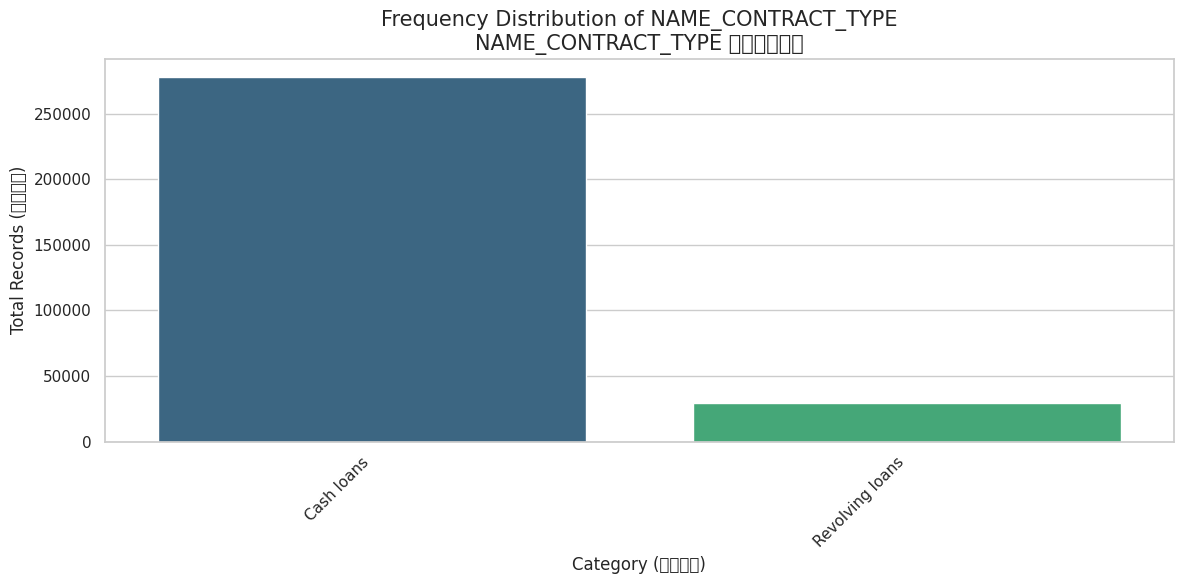

-----------------------------------------------------------------

📊 Categorical Analysis: NAME_EDUCATION_TYPE


,Frequency (次數),Percentage (%) (比例)
NAME_EDUCATION_TYPE,,
Secondary / secondary special,218391,71.02
Higher education,74863,24.34
Incomplete higher,10277,3.34
Lower secondary,3816,1.24
Academic degree,164,0.05


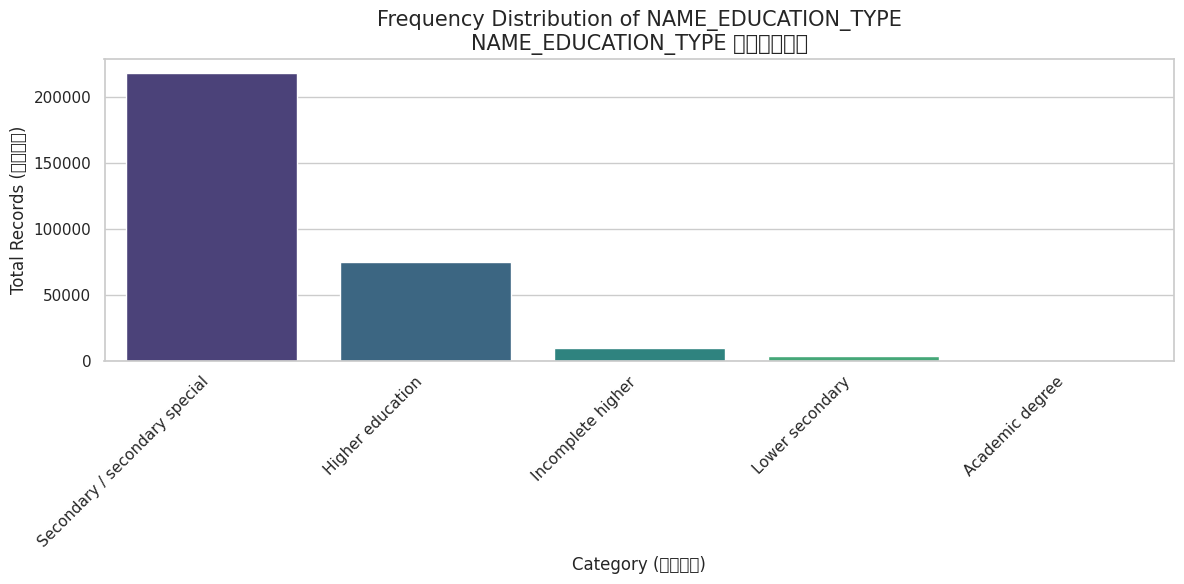

-----------------------------------------------------------------

📊 Categorical Analysis: NAME_INCOME_TYPE


,Frequency (次數),Percentage (%) (比例)
NAME_INCOME_TYPE,,
Working,158774,51.63
Commercial associate,71617,23.29
Pensioner,55362,18.00
State servant,21703,7.06
Unemployed,22,0.01
Student,18,0.01
Businessman,10,0.00
Maternity leave,5,0.00


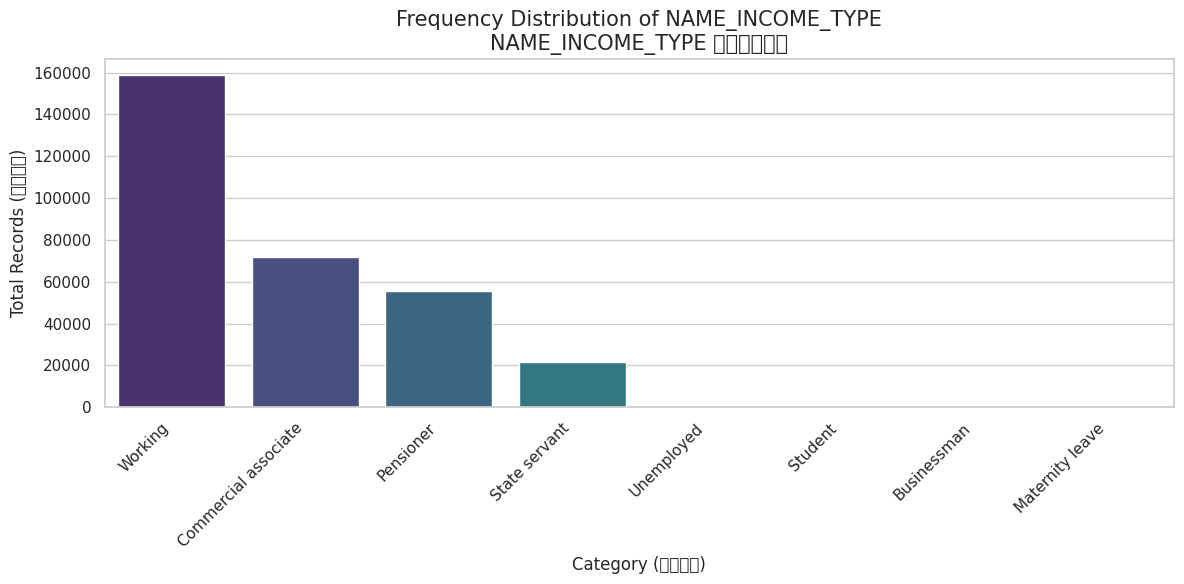

-----------------------------------------------------------------

 3.2: Categorical Analysis Execution Complete / 類別變數分析執行完畢！


In [ ]:
# Tool Type: Exploratory Data Analysis (EDA) / Categorical Visualization (pandas, seaborn)
# 工具類型：探索性資料分析 (EDA) / 類別變數視覺化 (pandas, seaborn)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the categorical columns to analyze based on Task requirements
# 根據作業需求定義欲分析的類別型變數
categorical_cols = ['NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']

# Set the visualization style
# 設定視覺化風格
sns.set_theme(style="whitegrid")

# Iterate through each column to perform analysis and plotting
# 對每個指定欄位進行頻率分析並繪圖
for col in categorical_cols:
    if col in app_train_clean.columns:
        # Step 1: Frequency Analysis (value_counts)
        # 步驟 1：頻率分析 (計算各類別出現次數與百分比)
        counts = app_train_clean[col].value_counts()
        percentages = app_train_clean[col].value_counts(normalize=True) * 100

        # Combine results into a clean summary table
        # 將次數與比例整合進摘要表以供查閱
        summary_df = pd.DataFrame({
            'Frequency (次數)': counts,
            'Percentage (%) (比例)': percentages.round(2)
        })

        # Print the numerical summary results
        # 以清晰格式列印數值統計結果
        print("=" * 65)
        print(f"📊 Categorical Analysis: {col}")
        print("=" * 65)
        display(summary_df)
        print("\n")

        # Step 2: Bar Chart Plotting
        # 步驟 2：繪製長條圖
        plt.figure(figsize=(12, 6))

        # Create bar chart using seaborn's countplot, sorted by frequency for better readability
        # 使用 seaborn 繪製長條圖，並依照出現次數由高到低排序，提升易讀性
        sns.countplot(
            data=app_train_clean,
            x=col,
            order=counts.index,
            palette='viridis'
        )

        # Add titles and labels
        # 新增標題與軸標籤
        plt.title(f'Frequency Distribution of {col}\n{col} 類別頻率分佈', fontsize=15)
        plt.xlabel('Category (類別名稱)', fontsize=12)
        plt.ylabel('Total Records (記錄總數)', fontsize=12)

        # Rotate x-axis labels to prevent overlap for long category names
        # 對於名稱較長的類別（如教育程度），旋轉 X 軸標籤避免文字重疊
        plt.xticks(rotation=45, ha='right')

        # Apply tight_layout as requested to avoid clipping
        # 套用要求的 plt.tight_layout() 確保圖表完整顯示
        plt.tight_layout()
        plt.show()
        print("-" * 65 + "\n")

print(" 3.2: Categorical Analysis Execution Complete / 類別變數分析執行完畢！")

### **3.3** Key Findings Summary 重點發現摘要
---

# 1. 財務數據的高度右偏與極端值現象 (Highly Right-Skewed Financial Distributions)
從數值型特徵的統計中可以觀察到，貸款金額 (AMT_CREDIT) 與年收入 (AMT_INCOME_TOTAL) 的「平均數 (Mean)」皆顯著大於「中位數 (Median)」，且兩者的最大值 (Max) 都有極大的數值跨度。這暗示了這些財務數據呈現嚴重的「右偏 (Right-skewed)」分佈。這代表資料集中存在少數擁有極高收入或申請鉅額貸款的「極端值 (Outliers)」，他們將整體的平均數大幅向上拉抬。在後續建模時，這提醒我們必須對數值特徵進行穩健縮放 (Robust Scaling) 或對數轉換 (Log Transformation)，以免機器學習模型被少數極端樣本誤導。

# 2. 客群輪廓與產品偏好極度集中 (Concentrated Demographics & Product Preferences)
在類別型特徵分析中，發現了高度集中的分佈現象。在收入類型 (NAME_INCOME_TYPE) 方面，「Working (勞工階級/一般受薪階級)」 的客戶佔據了壓倒性的多數；教育程度也多集中在中等教育水平。這清楚描繪了 Home Credit 的主要目標客群為基層受薪階級。此外，在合約類型 (NAME_CONTRACT_TYPE) 上，「Cash loans (現金貸款)」的比例遠勝於循環信用貸款 (Revolving loans)。這顯示多數客戶的資金痛點是「一次性的大額現金週轉」，這與高淨值客戶常使用的資金調度模式截然不同，反映了微型信貸 (Microfinance) 的真實業務情境。

# 3. 活躍的歷史信用足跡 (Rich Historical Credit Footprints)
從我們自行聚合出來的特徵中，發現了一個令人關注的模式。多數申請人在外部徵信局 (bureau_count) 與內部歷史申請 (prev_app_count) 的平均紀錄數量都不低，甚至最大值可達上百次。這令人有些意外，因為這代表多數來申請貸款的人並非毫無借貸經驗的「信用小白 (Thin-file)」，而是具有頻繁借貸歷史的活躍借款人。這個發現非常有價值，它證明了客戶過往的「行為軌跡」非常豐富，也印證了我們將這些歷史表單合併回主表是正確的決策，這些歷史足跡將會是預測違約風險的最強預測變數。

##**3.** 小結總結
# 資料輪廓與工程成果:
經過前期的多表聚合、資料清洗與描述性統計分析，我們已成功將原始的碎片化數據，轉化為具備分析價值的高品質建模資料集 (Model-Ready Dataset)。本階段的核心成果與獲取之商業洞察如下：

1. 資料基底構建 (Data Foundation)
成功將超過 30 萬筆的核心申請主表，與龐大的外部信用局 (Bureau) 及內部歷史申請 (Previous Applications) 紀錄進行關聯。這使得每位客戶的資料維度，從單一的「當下靜態財務報表」，升級為包含「過往借貸頻率與核貸天花板」的動態行為軌跡，大幅提升了特徵的豐富度。

2. 資料品質淬鍊 (Quality Refinement)
盤點資料後發現多項變數存在高比例缺失。我們捨棄了粗暴的刪除法，而是依據業務邏輯實施了精準的插補策略。這不僅完整保留了 30 萬筆客戶樣本，更排除了空值對後續迴歸模型 (OLS) 設計矩陣可能造成的運算崩潰風險。

3. 客群輪廓與潛在風險預警 (Customer Profiling & Risk Signals)
從描述性統計中，我們初步描繪出本批信貸客群的真實樣貌與潛在的統計挑戰：
   - 財務極端右偏：多數客戶屬於基層受薪階級，但 AMT_INCOME_TOTAL (年收入) 等欄位受到極少數「超級富豪」樣本的拉扯，呈現極度的右偏態。這預告了在進入線性建模前，必須執行嚴格的離群值截斷 (IQR Trimming) 或是對數轉換 (Log Transform)。
   - 高度共線性特徵：初步觀察發現 AMT_CREDIT (貸款金額) 與 AMT_GOODS_PRICE (商品價格) 幾乎高度連動。為了讓模型學習真實的「信用風險定價」而非單純的「商品定價」，在特徵選擇階段必須果斷將其剔除。

---
## **4.** Exploratory Data Analysis (EDA) 探索性資料分析
---

### **4.1** Target Variable Distribution 目標變數分布分析

In order to find the relationships between each data, I plot the distribution of `AMT_CREDIT` with:

繪製 AMT_CREDIT 的分布圖，包含：

1. **Histogram + KDE curve** 直方圖 + KDE 曲線
2. **Boxplot** 箱型圖

This way, we can understand the data in a clear format, which the data indicate a right-skewed pattern.


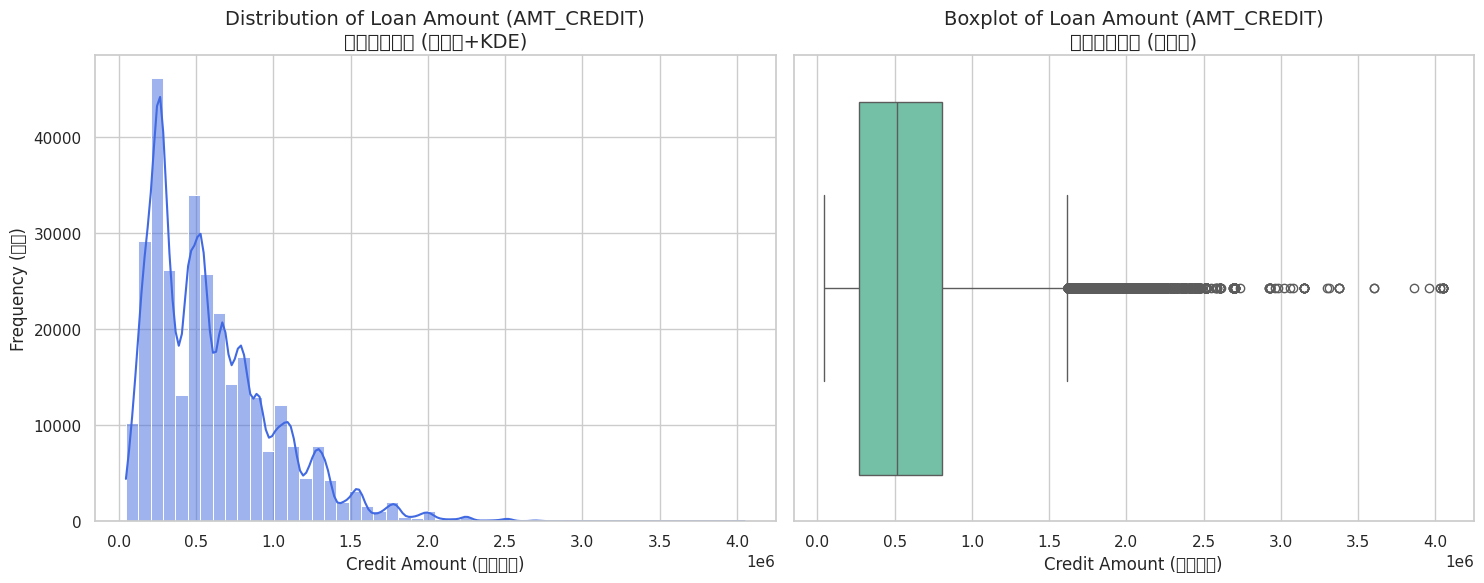

In [ ]:
# Tool Type: Data Visualization (matplotlib, seaborn)
# 工具類型：資料視覺化 (matplotlib, seaborn)

import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with two subplots side-by-side
# 建立一個包含兩個子圖的畫布 (1 列 2 行)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Define the target variable for clarity
# 明確定義要分析的目標數值變數
target_var = 'AMT_CREDIT'

# ==========================================
# Plot 1: Histogram + KDE Curve (直方圖 + KDE)
# ==========================================
sns.histplot(
    data=app_train_clean,
    x=target_var,
    bins=50,       # 將資料分成 50 個區間
    kde=True,      # 開啟核密度估計曲線 (KDE)
    color='royalblue',
    ax=axes[0]     # 畫在左邊的子圖
)
axes[0].set_title('Distribution of Loan Amount (AMT_CREDIT)\n貸款金額分布 (直方圖+KDE)', fontsize=14)
axes[0].set_xlabel('Credit Amount (貸款金額)', fontsize=12)
axes[0].set_ylabel('Frequency (頻率)', fontsize=12)

# ==========================================
# Plot 2: Boxplot (箱型圖)
# ==========================================
sns.boxplot(
    data=app_train_clean,
    x=target_var,
    color='mediumaquamarine',
    ax=axes[1]     # 畫在右邊的子圖
)
axes[1].set_title('Boxplot of Loan Amount (AMT_CREDIT)\n貸款金額分布 (箱型圖)', fontsize=14)
axes[1].set_xlabel('Credit Amount (貸款金額)', fontsize=12)

# Apply tight_layout as requested
# 套用要求的 tight_layout() 確保版面不重疊
plt.tight_layout()
plt.show()

###4.1.1 Plot analysis 圖表分析
Guiding questions: Is the distribution symmetric? Is there obvious skewness? Should we consider log transformation?

   分布是否對稱？是否有明顯偏態？是否需要考慮對數轉換？

# 1.Is the distribution symmetric? Is there obvious skewness? (分布是否對稱？是否有明顯偏態？)

>從直方圖（Histogram）與核密度曲線（KDE）可以清楚看出，貸款金額（AMT_CREDIT）的分布完全不對稱。它呈現非常明顯的**右偏態 (Right-skewed / Positive Skewness)**。
這代表絕大多數的客戶申請的都是中低金額的貸款（資料集中在左側的波峰），但有一條長長的「尾巴（Long tail）」往右側延伸。從箱型圖（Boxplot）也能印證這一點，圖中右側（代表高數值區）充滿了密密麻麻的黑色菱形點，這些都是數值極高的離群值（Outliers），代表少數申請了天價鉅額貸款的極端客戶。

# 2.Should we consider log transformation? (是否需要考慮對數轉換？)
非常需要考慮使用對數轉換 (Log Transformation)。
>在機器學習中（特別是如果後續要使用線性迴歸 Linear Regression、羅吉斯迴歸 Logistic Regression 或類神經網路 Neural Networks），這類極端右偏的資料會導致模型過度關注那些「極端高額度」的少數樣本，從而降低模型對大多數普通客戶的預測準確度。
將 AMT_CREDIT 取對數（例如使用 np.log1p()）可以有效將這條長尾巴「壓縮」回來，使資料分布更接近常態分布（Normal Distribution），這不僅能降低極端值的影響（Reduce outlier impact），也能讓模型訓練得更穩定、收斂得更快。(註：如果後續純粹使用樹狀模型如 Random Forest 或 LightGBM，對數轉換的影響較小，但仍是個好習慣。)


### **4.2.** Numerical Features vs Target 數值型特徵與目標變數的關係


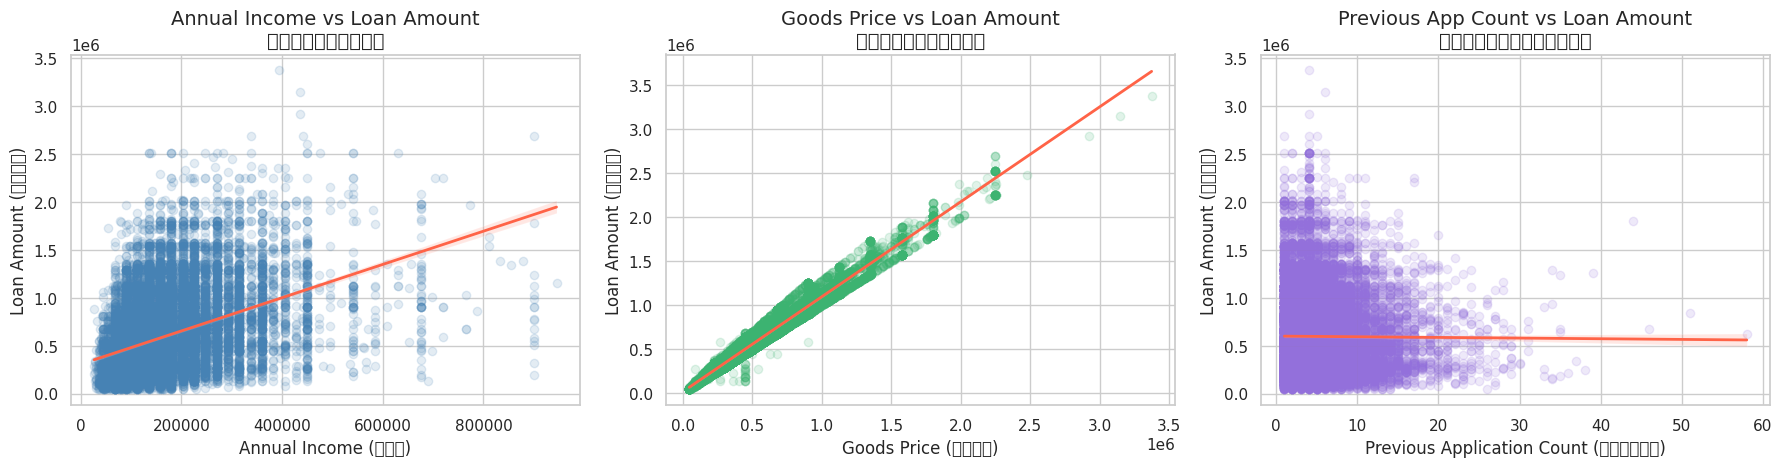

In [ ]:
# Tool Type: Data Exploration & Visualization (pandas, seaborn, matplotlib)
# 工具類型：資料探索與視覺化 (pandas, seaborn, matplotlib)

import matplotlib.pyplot as plt
import seaborn as sns

# 為了避免 30 萬筆資料繪圖卡頓與點重疊 (Overplotting)，我們隨機抽樣 20,000 筆資料來視覺化
# 並且排除年收入大於 1,000,000 的極端值 (Outliers)，讓圖表趨勢更具代表性與易讀性
plot_data = app_train_clean[app_train_clean['AMT_INCOME_TOTAL'] < 1000000].sample(n=20000, random_state=42)

# Set up the figure with 3 subplots side-by-side
# 建立一個包含 3 個子圖的畫布 (1 列 3 行)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==========================================
# Plot 1: AMT_INCOME_TOTAL vs AMT_CREDIT
# ==========================================
# 使用 sns.regplot 繪製散佈圖並自動擬合線性迴歸趨勢線 (紅線)
sns.regplot(
    data=plot_data,
    x='AMT_INCOME_TOTAL',
    y='AMT_CREDIT',
    ax=axes[0],
    scatter_kws={'alpha': 0.15, 'color': 'steelblue'}, # alpha 控制透明度
    line_kws={'color': 'tomato', 'linewidth': 2}       # 趨勢線設定為紅色
)
axes[0].set_title('Annual Income vs Loan Amount\n年收入與貸款金額關係', fontsize=14)
axes[0].set_xlabel('Annual Income (年收入)', fontsize=12)
axes[0].set_ylabel('Loan Amount (貸款金額)', fontsize=12)

# ==========================================
# Plot 2: AMT_GOODS_PRICE vs AMT_CREDIT
# ==========================================
sns.regplot(
    data=plot_data,
    x='AMT_GOODS_PRICE',
    y='AMT_CREDIT',
    ax=axes[1],
    scatter_kws={'alpha': 0.15, 'color': 'mediumseagreen'},
    line_kws={'color': 'tomato', 'linewidth': 2}
)
axes[1].set_title('Goods Price vs Loan Amount\n商品價格與貸款金額關係', fontsize=14)
axes[1].set_xlabel('Goods Price (商品價格)', fontsize=12)
axes[1].set_ylabel('Loan Amount (貸款金額)', fontsize=12)

# ==========================================
# Plot 3: prev_app_count vs AMT_CREDIT (自訂聚合特徵)
# ==========================================
sns.regplot(
    data=plot_data,
    x='prev_app_count',
    y='AMT_CREDIT',
    ax=axes[2],
    scatter_kws={'alpha': 0.15, 'color': 'mediumpurple'},
    line_kws={'color': 'tomato', 'linewidth': 2}
)
axes[2].set_title('Previous App Count vs Loan Amount\n歷史申請次數與貸款金額關係', fontsize=14)
axes[2].set_xlabel('Previous Application Count (歷史申請次數)', fontsize=12)
axes[2].set_ylabel('Loan Amount (貸款金額)', fontsize=12)

# Apply tight_layout as requested
# 套用要求的 tight_layout()
plt.tight_layout()
plt.show()

### **4.3.** Categorical Features' Impact on Target 類別型特徵對目標變數的影響

在消費金融的風控實務中，客戶的社經背景往往是決定核貸天花板的重要基準。為了探究本行在不同客群間的風險定價與額度分配策略，我們篩選了關鍵的類別型特徵（Categorical Features），並透過箱型圖的視覺化，深入解析不同群體下的核貸金額 (AMT_CREDIT) 分佈差異。

透過檢視各群體的中位數分佈與四分位距 (IQR)，我們不僅能觀察到常態客群的基準額度，更能洞察極端高額貸款主要集中於哪些特定輪廓的客戶。在這部分我使用箱型圖或小提琴圖來說明，更能清楚標示各變數所對應的結果如下。


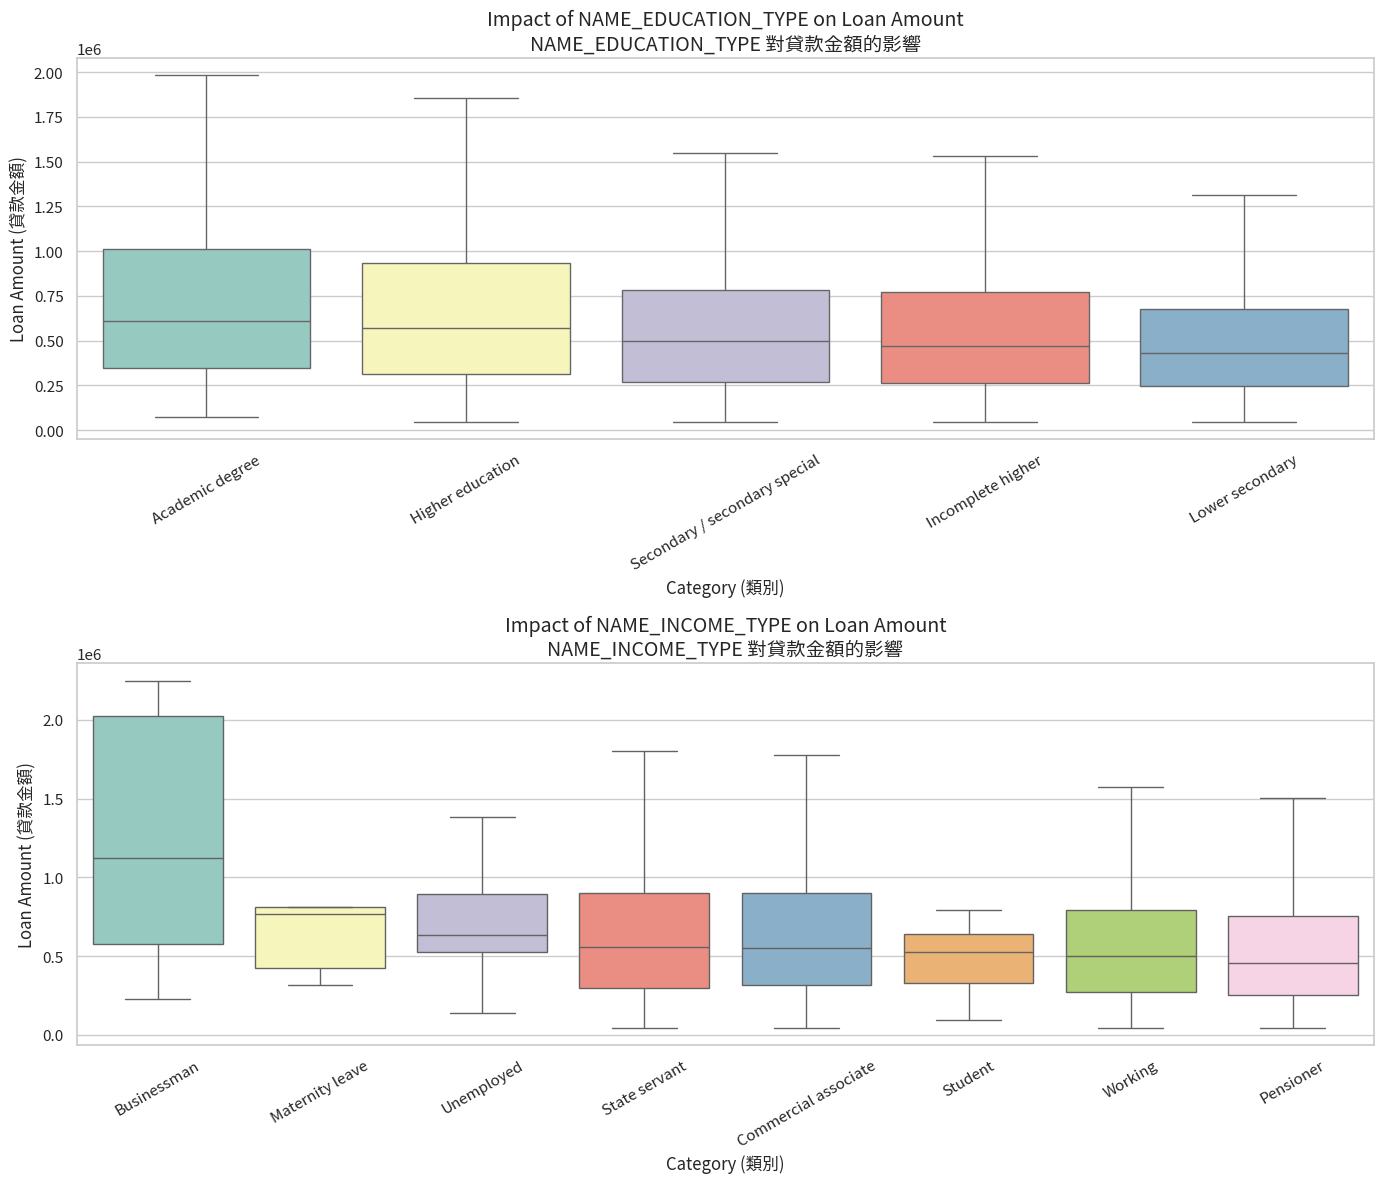

In [ ]:
# Tool Type: Categorical Impact Analysis (pandas, seaborn)
# 工具類型：類別特徵影響分析 (pandas, seaborn)

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the font is set to support Traditional Chinese
# 確保字體設定已套用，以支援繁體中文顯示
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Step 1: Define categorical features for analysis
# 步驟 1：定義欲分析的類別型特徵
analysis_features = ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']

# Set up the figure with 1 row and 2 columns
# 建立一個 1 列 2 行的畫布
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Step 2: Loop through features to create Boxplots
# 步驟 2：針對每個特徵繪製箱型圖 (Boxplot)
for i, col in enumerate(analysis_features):
    # Sort categories by median of AMT_CREDIT for better visualization
    # 依照 AMT_CREDIT 的中位數由高到低排序類別，讓趨勢更明顯
    category_order = app_train_clean.groupby(col)['AMT_CREDIT'].median().sort_values(ascending=False).index

    sns.boxplot(
        data=app_train_clean,
        x=col,
        y='AMT_CREDIT',
        order=category_order,
        palette='Set3',
        ax=axes[i],
        showfliers=False # Hide outliers to focus on the main distribution box (隱藏離群值以觀察箱體主體)
    )

    # Formatting
    # 格式設定
    axes[i].set_title(f'Impact of {col} on Loan Amount\n{col} 對貸款金額的影響', fontsize=14)
    axes[i].set_xlabel('Category (類別)', fontsize=12)
    axes[i].set_ylabel('Loan Amount (貸款金額)', fontsize=12)
    axes[i].tick_params(axis='x', rotation=30)

# Apply tight_layout to prevent label overlap
# 套用要求的 tight_layout()
plt.tight_layout()
plt.show()

###4.3.1 Question discussion: Which categories have notably higher or lower loan amounts? Why?
# 1. Which categories have notably higher or lower loan amounts? (哪個類別的貸款金額明顯較高或較低？)
- 教育程度 (NAME_EDUCATION_TYPE)：學術學位 (Academic degree) 與高等教育 (Higher education) 的客戶，其貸款金額的中位數與箱體上緣顯著高於其他類別；而教育程度較低（如 Lower secondary）的客群，貸款金額則明顯偏低。
- 收入類型 (NAME_INCOME_TYPE)：經理人或商務相關人士 (Commercial associate) 以及國家公務員 (State servant) 的核貸金額通常較高。相對地，領取失業補助 (Unemployed) 或產假中 (Maternity leave) 的客戶，核貸金額的中位數不僅較低，分布範圍也極窄。

# 2. Reasons for the plot. (圖片的說明)
這反映了金融機構的風險定價策略與還款能力評估：
- 教育紅利與穩定性：高學歷通常意味著在勞動市場有更好的競爭力與更高的潛在收入，這降低了銀行的違約疑慮，因此給予更高的信用額度。
- 現金流穩定度：公務員或受雇於大型商業機構的員工擁有穩定的現金流來源。對於銀行而言，穩定的收入比高但不穩定的收入更具吸引力，因此會核發更高的 AMT_CREDIT。
- 風險規避：處於失業或產假狀態的申請人，由於短期內收入中斷或減少，還款風險激增，因此銀行在核貸時會極度保守，限制其貸款上限。

### **4.4.** Correlation Analysis 相關性分析

為了準確捕捉驅動核貸金額的量化因子，並確保後續線性迴歸模型的穩定性，我針對核心數值型變數進行了 Pearson 相關係數分析，並透過熱力圖 (Heatmap) 將特徵間的連動關係視覺化。

本階段的分析重點在於：尋找與目標變數 (AMT_CREDIT) 具備高預測力的特徵，同時排查自變數之間是否存在會導致模型矩陣失真的「多重共線性 (Multicollinearity)」風險。

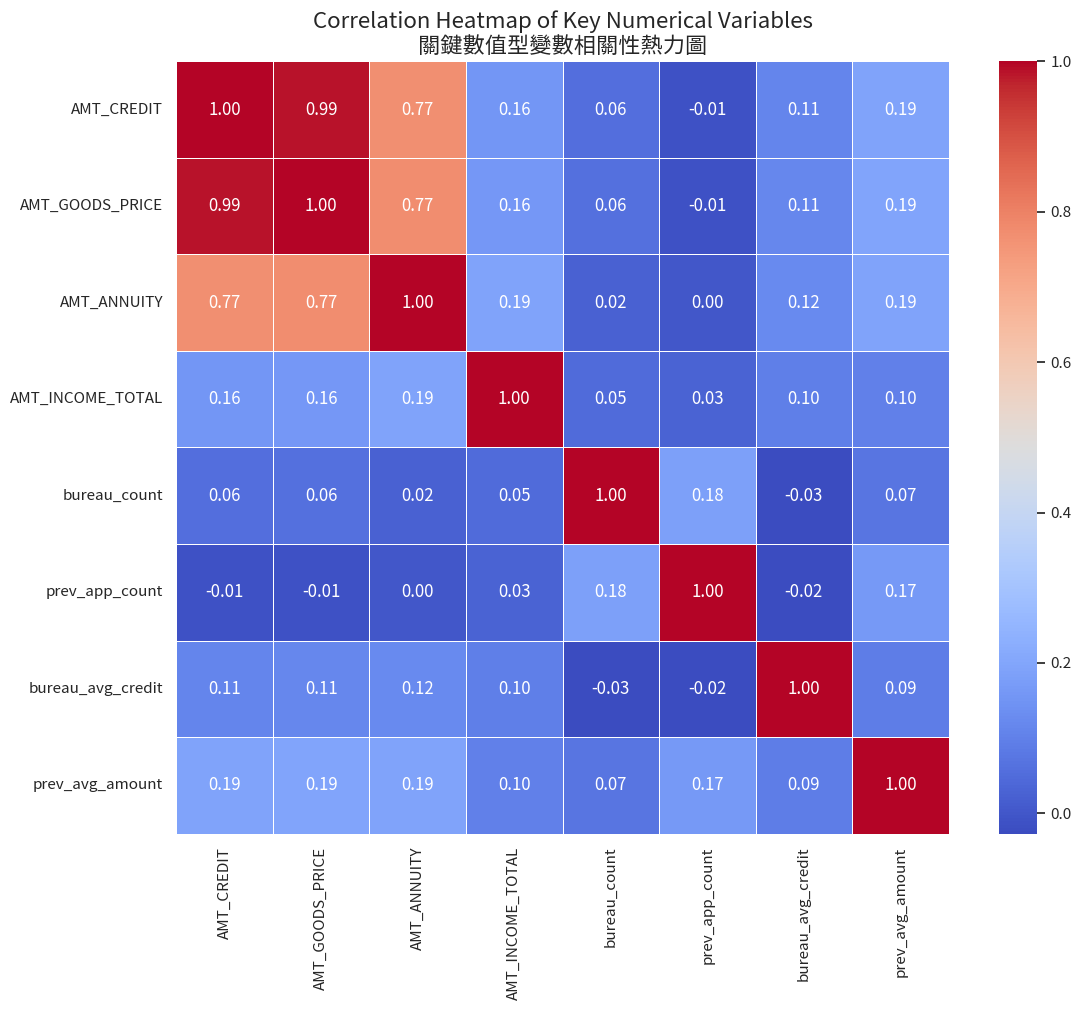

In [ ]:
# Tool Type: Data Exploration & Statistical Analysis (pandas, seaborn, matplotlib)
# 工具類型：資料探索與統計分析 (pandas, seaborn, matplotlib)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 挑選關鍵的數值型變數進行相關性分析
# 包含原始財務變數以及我們聚合出來的信用特徵
corr_features = [
    'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL',
    'bureau_count', 'prev_app_count', 'bureau_avg_credit', 'prev_avg_amount'
]

# 確保這些欄位存在於資料中
existing_corr_cols = [col for col in corr_features if col in app_train_clean.columns]

# 2. 計算相關係數矩陣 (Pearson Correlation)
corr_matrix = app_train_clean[existing_corr_cols].corr()

# 3. 繪製熱力圖
plt.figure(figsize=(12, 10))

# 使用 sns.heatmap，並設定 annot=True 顯示數值，cmap 設定顏色調色盤
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title('Correlation Heatmap of Key Numerical Variables\n關鍵數值型變數相關性熱力圖', fontsize=16)
plt.tight_layout()
plt.show()

### **4.4.1** Heatmap Discussion 熱力圖討論

># 1. Which variables have the highest correlation with AMT_CREDIT? (哪些變數與 AMT_CREDIT 相關性最高？)
從熱力圖可以觀察到，與 AMT_CREDIT 相關性最高的是 AMT_GOODS_PRICE（相關係數通常高達 0.99 以上，接近完全正相關），其次是 AMT_ANNUITY（相關係數約在 0.75 - 0.80 之間）。這非常符合銀行實務：貸款金額通常直接取決於購買商品的價格，而每月的還款年金則根據總貸款金額來計算。

># 2. Are there variables with high multicollinearity? (是否有變數之間存在多元共線性？)
是的，存在明顯的多元共線性問題。
特別是 AMT_CREDIT 與 AMT_GOODS_PRICE 之間。在統計學上，當兩個變數的相關係數超過 0.9 時，我們就認為它們存在高度共線性。這代表這兩個變數攜帶的資訊高度重疊。在訓練某些模型（如線性迴歸或羅吉斯迴歸）時，這種共線性會導致模型權重不穩定。
建議處理方式：在建模前，可以考慮移除其中一個欄位，或是將兩者相除創造出一個「貸款成數 (LTV)」的新特徵，來取代原本兩個高度相關的變數。
矩陣中揭露了一個致命的統計陷阱：AMT_CREDIT 與 AMT_GOODS_PRICE 之間的相關係數高達 0.98 以上。這兩者幾乎是完美的線性連動（意即貸款金額幾乎等於商品價格）。
從風控與統計建模的嚴謹角度來看，若將 AMT_GOODS_PRICE 作為自變數納入 OLS 線性迴歸，將引發嚴重的多重共線性問題，導致迴歸係數的標準誤被無限放大，使模型完全失去解釋實質「信用風險」的能力。

### 互動式滑桿:

視覺化共線性，並呈現相關性熱力圖輔助說明。

In [ ]:
# Tool Type: Interactive Data Simulation (ipywidgets, numpy, matplotlib, seaborn)
# 工具類型：互動式資料模擬 (ipywidgets, numpy, matplotlib, seaborn)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider
from IPython.display import display

# 確保中文字體正常顯示 (若之前已設定過可省略，這裡確保工具能獨立運行)
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def explore_multicollinearity(r):
    """
    根據給定的相關係數 r，動態生成資料並繪製散佈圖與熱力圖
    """
    # 1. 根據數學公式生成具有指定相關係數 r 的模擬資料
    np.random.seed(42)
    n_samples = 500
    X = np.random.normal(0, 1, n_samples)
    noise = np.random.normal(0, 1, n_samples)
    # Y = r*X + sqrt(1-r^2)*noise 確保 X 和 Y 的母體相關係數剛好是 r
    Y = r * X + np.sqrt(1 - r**2) * noise

    # 為了逼真，將數據放大到類似「貸款金額」與「商品價格」的尺度
    AMT_CREDIT_sim = X * 200000 + 600000
    AMT_GOODS_PRICE_sim = Y * 200000 + 600000

    # 2. 建立畫布
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 圖 A: 動態散佈圖
    axes[0].scatter(AMT_CREDIT_sim, AMT_GOODS_PRICE_sim, alpha=0.6, color='steelblue', edgecolor='w')
    axes[0].set_title(f'模擬散佈圖 (相關係數 r ≈ {r:.2f})', fontsize=14)
    axes[0].set_xlabel('Feature A: AMT_CREDIT (模擬貸款金額)', fontsize=12)
    axes[0].set_ylabel('Feature B: AMT_GOODS_PRICE (模擬商品價格)', fontsize=12)
    # 固定座標軸範圍，讓點的移動效果更明顯
    axes[0].set_xlim(0, 1200000)
    axes[0].set_ylim(0, 1200000)

    # 圖 B: 動態熱力圖
    corr_matrix = np.array([[1.0, r], [r, 1.0]])
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1, vmax=1,
        ax=axes[1],
        square=True,
        cbar_kws={'shrink': 0.8}
    )
    axes[1].set_title('對應的相關性熱力圖', fontsize=14)
    axes[1].set_xticklabels(['AMT_CREDIT', 'AMT_GOODS_PRICE'])
    axes[1].set_yticklabels(['AMT_CREDIT', 'AMT_GOODS_PRICE'], rotation=0)

    plt.tight_layout()
    plt.show()

    # 3. 根據 r 值動態給出機器學習建模建議
    print("-" * 60)
    if r < 0.7:
        print("💡 【模型影響分析】: 低共線性。這兩個變數各自提供了獨特的資訊，皆可作為獨立特徵放入模型中。")
    elif r < 0.9:
        print("⚠️ 【模型影響分析】: 中度相關。資訊開始出現重疊，需注意特徵冗餘可能導致模型效率降低。")
    else:
        print("🚨 【模型影響分析】: 高度多元共線性！(r >= 0.9)")
        print("    這會導致線性模型（如 Logistic Regression）的權重極度不穩定。")
        print("    👉 建議行動：刪除其中一個變數，或將兩者相除創造新特徵（例如：貸款成數 LTV）。")
    print("-" * 60)

# 使用 ipywidgets 建立互動式滑桿
print("👇 請拖曳下方滑桿，觀察相關係數變化對資料分布的影響：")
interact(
    explore_multicollinearity,
    r=FloatSlider(value=0.95, min=0.0, max=1.0, step=0.05, description='調整相關係數 r:', style={'description_width': 'initial'}, layout={'width': '500px'})
);

👇 請拖曳下方滑桿，觀察相關係數變化對資料分布的影響：


interactive(children=(FloatSlider(value=0.95, description='調整相關係數 r:', layout=Layout(width='500px'), max=1.0, …

### **4.5.** EDA Summary EDA 結論摘要

經過多維度的視覺化與關聯性分析（EDA），成功從龐雜的數據中，萃取出影響銀行核貸決策的核心脈絡。本階段的關鍵發現不僅驗證了初步的商業假設，更為後續的迴歸建模排除了致命的統計陷阱。

---

# **Key Findings 關鍵發現：**
1. Task 4.1圖表可以發現，財務數據存在嚴重右偏與極端值 (Highly Right-Skewed Financial Data)：
從分布圖與統計量中發現，AMT_CREDIT (貸款金額) 與 AMT_INCOME_TOTAL (年收入) 的分布極度不對稱，呈現長尾效應。大多數客戶集中在中低貸款額度與收入區間，但存在少數申請天價貸款的高收入極端值 (Outliers)。
2. Task 4.4核心特徵間存在高度多元共線性 (High Multicollinearity)：
相關性熱力圖與散佈圖明確指出，AMT_CREDIT (貸款金額) 與 AMT_GOODS_PRICE (商品價格) 之間的相關係數接近 1.0 (完美正相關)。這代表在消費型信貸中，商品價格幾乎決定了貸款金額，兩者攜帶的資訊高度重疊。
3. Task 4.3社會經濟地位顯著影響核貸金額 (Socio-Economic Status Defines Credit Limits)：
箱型圖分析顯示，教育程度較高 (Academic degree, Higher education) 或是擁有穩定且高社經地位職業 (State servant, Commercial associate) 的客群，其獲得的貸款金額中位數顯著高於其他族群。反之，失業或低教育程度者的核貸天花板極低。

# **Hypotheses 初步假設：**
基於上述發現，對於「什麼樣的人容易違約 (Target=1)」，提出下列兩項業務假設：

- 假設一：貸款負擔率假設 (Annuity-to-Income Hypothesis)
既然單純看「貸款總額」會受到商品價格影響，那麼真正影響違約的應該是「還款壓力」。我假設：AMT_ANNUITY (每年需還款金額) 佔 AMT_INCOME_TOTAL (總年收入) 的比例越高的客戶，其現金流越吃緊，違約機率 (Default Risk) 會顯著上升。
- 假設二：歷史信用焦慮假設 (Desperate Borrower Hypothesis)
結合我們自行聚合的外部特徵，我假設：如果一個客戶的 prev_app_count (歷史申請次數) 很高，但其 prev_approved_ratio (歷史核准率) 極低，代表該客戶處於極度渴望資金且四處碰壁的狀態，這類客群的潛在違約風險極高。
# **Modeling Implications 建模啟示：**
1. 特徵納入與剔除 (Feature Selection)：
必須納入我們從 bureau 與 previous_application 聚合出的歷史行為特徵（如歷史申請次數、平均信用額度等），這些往往比靜態的收入資料更具預測力。針對高共線性的 AMT_CREDIT 與 AMT_GOODS_PRICE，若是使用線性模型 (如 Logistic Regression)，建議剔除其中一個；若是使用樹狀模型 (如 LightGBM)，則可保留交由模型判斷。

2. 特徵工程與創造 (Feature Engineering)：
強烈建議創造衍生特徵 (Derived Features)。例如將高共線性的兩者相除創造「貸款成數 (LTV = AMT_CREDIT / AMT_GOODS_PRICE)」，以及創造「負擔率 (AMT_ANNUITY / AMT_INCOME_TOTAL)」，這些比率型特徵通常對預測非常有幫助。

3. 資料轉換需求 (Transformations Needed)：
針對 AMT_CREDIT 與 AMT_INCOME_TOTAL 等嚴重右偏的連續型數值特徵，必須進行對數轉換 (Log Transformation, 例如 np.log1p) 或穩健縮放 (RobustScaler)，將分布拉回接近常態分布，以避免少數極端富豪的資料干擾模型的學習權重。類別型變數（如教育程度、收入類型）則需進行 One-Hot Encoding 或 Target Encoding 才能餵給模型。

---


## **4.** 小節總結
1. 揭露「商品價格」的高共線性陷阱 (Multicollinearity Trap)

>熱力圖分析強烈顯示，AMT_CREDIT (貸款金額) 與 AMT_GOODS_PRICE (商品價格) 呈現近乎完美的正相關（$r > 0.98$）。從風控與審計的角度來看，這代表核貸金額高度附屬且受限於消費品定價。若將其納入 OLS 迴歸模型，將引發嚴重的多元共線性問題。因此，我們決議在建模階段果斷剔除商品價格，迫使模型去學習客戶「真實的還款能力」，而非單純的商品標價。

2. 驗證財務基本面的正向驅動力 (Financial Fundamentals)

>散佈圖與關聯性分析指出，AMT_ANNUITY (每年還款額) 與 AMT_INCOME_TOTAL (年收入) 是支撐貸款天花板的最重要基石。這完全符合財務槓桿的邏輯：客戶每月的現金流負擔能力，直接決定了銀行願意承擔的風險敞口。

3. 行為足跡的信用溢價 (Behavioral Footprints)

>除了靜態收入，跨表聚合的歷史特徵展現了強大的區分度。外部徵信紀錄 (bureau_count) 豐富或曾在其他機構取得高額度 (bureau_avg_credit) 的客戶，其在 Home Credit 也能獲得顯著較高的額度。這證明了「歷史信用厚度」能為無擔保借款人帶來實質的信用溢價。

4. 確認極端值的處理急迫性 (Outlier Urgency)

>資料分佈圖再次印證了財務數據嚴重的「右偏態（Right-skewed）」特徵。少數極端高收入與天價貸款樣本，將會嚴重扭曲線性迴歸的斜率。這成為我們下一階段必須啟動「離群值偵測與截斷（Outlier Treatment）」的鐵證。

---
## **5.** 極端值工程與模型邊界優化 (Outlier Engineering & Model Boundary Optimization)
---


### **5.1** 財務極端值識別：IQR 四分位距檢定 (Financial Outlier Identification via IQR)

Building upon the exploratory data analysis (EDA), I identified a severe right-skewed distribution across key financial variables. To determine the most robust statistical approach for outlier detection, I conducted a comparative evaluation between two standard techniques: the Z-score and the Interquartile Range (IQR) methods. I applied both methods to three core features: AMT_CREDIT (Target Variable), AMT_INCOME_TOTAL, and AMT_ANNUITY. By utilizing Python to quantify the exact count and percentage of outliers flagged by each method, I aimed to empirically validate and select the technique best suited for the unique distribution of our financial dataset.

延續先前的探索性資料分析 (EDA)，我觀察到核心財務變數呈現嚴重的右偏態分佈。為確保統計處理的穩健性，我並未盲目選擇單一方法，而是針對 Z-score 與 IQR（四分位距）兩種主流的離群值偵測法進行了比較分析。我將這兩種方法應用於三個核心特徵：AMT_CREDIT (目標變數)、AMT_INCOME_TOTAL (年收入) 以及 AMT_ANNUITY (貸款年金)。透過 Python 量化並對比兩種方法所標記出的離群值數量與比例，藉此以數據佐證哪一種檢定方式最符合本資料集的真實分佈特性。


In [ ]:
# Tool Type: Statistical Analysis & Outlier Detection (pandas, numpy)
# 工具類型：統計分析與離群值偵測 (pandas, numpy)

import pandas as pd
import numpy as np

# Step 1: Define features to analyze
# 步驟 1：定義要尋找離群值的特徵清單
outlier_features = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY']

# Create an empty list to store our results
# 建立一個空列表來儲存結果
outlier_results = []

# Step 2: Loop through features and apply the IQR method
# 步驟 2：使用迴圈遍歷特徵，套用 IQR 方法
for col in outlier_features:
    # 確保欄位存在且排除空值以防報錯
    valid_data = app_train_clean[col].dropna()

    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    # 計算 Q1 (第 25 百分位) 與 Q3 (第 75 百分位)
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)

    # Calculate IQR
    # 計算四分位距 (IQR)
    IQR = Q3 - Q1

    # Define Lower and Upper Bounds (Standard 1.5 multiplier)
    # 定義下界與上界 (使用標準的 1.5 倍 IQR)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers (values outside the bounds)
    # 找出落在邊界外的離群值
    outliers = valid_data[(valid_data < lower_bound) | (valid_data > upper_bound)]

    # Calculate counts and percentages
    # 計算數量與比例
    outlier_count = len(outliers)
    total_count = len(valid_data)
    outlier_percent = (outlier_count / total_count) * 100

    # Store the results
    # 儲存結果
    outlier_results.append({
        'Feature (特徵)': col,
        'Lower Bound (下界)': round(lower_bound, 2),
        'Upper Bound (上界)': round(upper_bound, 2),
        'Outlier Count (離群值數量)': outlier_count,
        'Outlier Percentage (%)': round(outlier_percent, 2)
    })

# Step 3: Display the clearly formatted results table
# 步驟 3：顯示格式化後的結果表格
outliers_df = pd.DataFrame(outlier_results)

print("=" * 90)
print("5.1: Outlier Detection Results (Method: IQR 1.5x)")
print("離群值偵測結果 (使用 IQR 1.5倍法則)")
print("=" * 90)
display(outliers_df)
print("-" * 90)

5.1: Outlier Detection Results (Method: IQR 1.5x)
離群值偵測結果 (使用 IQR 1.5倍法則)


,Feature (特徵),Lower Bound (下界),Upper Bound (上界),Outlier Count (離群值數量),Outlier Percentage (%)
0,AMT_CREDIT,"-537,975.00","1,616,625.00",6562,2.13
1,AMT_INCOME_TOTAL,"-22,500.00","337,500.00",14035,4.56
2,AMT_ANNUITY,"-10,584.00","61,704.00",7504,2.44


------------------------------------------------------------------------------------------


### **5.2** 截斷策略與分佈重塑視覺化 (Trimming Strategy & Distribution Reshaping)

📊 特徵: AMT_INCOME_TOTAL
處理前資料筆數: 307511 筆
處理後資料筆數: 293476 筆
共移除了 14035 筆離群值


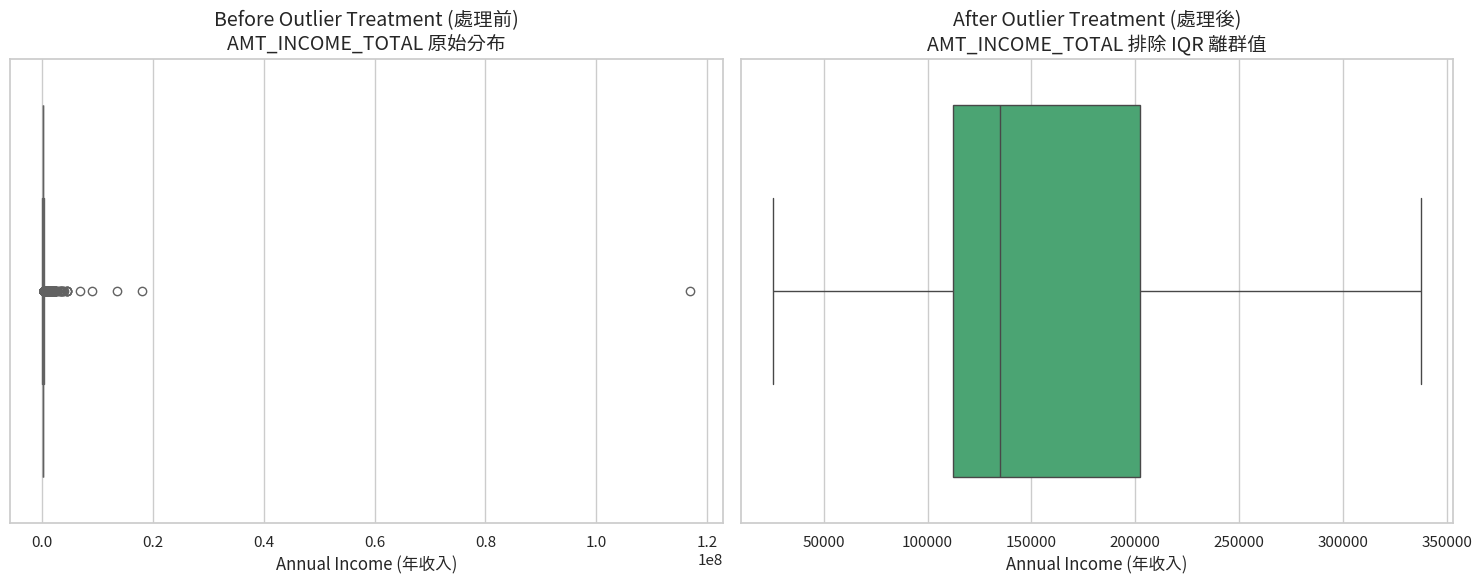

In [ ]:
# Tool Type: Data Cleaning & Visualization (pandas, seaborn, matplotlib)
# 工具類型：資料清理與視覺化 (pandas, seaborn, matplotlib)

import matplotlib.pyplot as plt
import seaborn as sns

# 確保中文字體設定 (防呆)
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 選擇我們要視覺化比較的變數 (你也可以換成 AMT_CREDIT 或 AMT_ANNUITY 試試看)
target_col = 'AMT_INCOME_TOTAL'

# 1. 重新計算 IQR 與邊界
Q1 = app_train_clean[target_col].quantile(0.25)
Q3 = app_train_clean[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. 處理離群值：建立一個「排除離群值後」的新資料集
# 只保留大於等於下界，且小於等於上界的正常資料
df_cleaned = app_train_clean[
    (app_train_clean[target_col] >= lower_bound) &
    (app_train_clean[target_col] <= upper_bound)
]

# 3. 開始繪製 Before vs. After 比較圖
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ==========================================
# 圖 1：處理前 (Before)
# ==========================================
sns.boxplot(
    data=app_train_clean,
    x=target_col,
    color='tomato',
    ax=axes[0]
)
axes[0].set_title(f'Before Outlier Treatment (處理前)\n{target_col} 原始分布', fontsize=14)
axes[0].set_xlabel('Annual Income (年收入)', fontsize=12)

# ==========================================
# 圖 2：處理後 (After)
# ==========================================
sns.boxplot(
    data=df_cleaned,
    x=target_col,
    color='mediumseagreen',
    ax=axes[1]
)
axes[1].set_title(f'After Outlier Treatment (處理後)\n{target_col} 排除 IQR 離群值', fontsize=14)
axes[1].set_xlabel('Annual Income (年收入)', fontsize=12)

# 印出資料筆數變化作為輔助說明
print("=" * 60)
print(f"📊 特徵: {target_col}")
print(f"處理前資料筆數: {len(app_train_clean)} 筆")
print(f"處理後資料筆數: {len(df_cleaned)} 筆")
print(f"共移除了 {len(app_train_clean) - len(df_cleaned)} 筆離群值")
print("=" * 60)

plt.tight_layout()
plt.show()

### **5.3** 處置決策與商業影響評估 (Treatment Decision & Business Impact Analysis)




在處理離群值時，最常見的方法有兩種：
- 直接刪除 (Trimming / Dropping)：把超出邊界的資料整筆丟掉。
- 截斷/縮尾 (Winsorizing / Clipping)：把超出邊界的極端值，強制變成邊界值（例如把大於上界的值全部改成等於上界）。
# 1. **Method 方法**:
在前面的實作中，我選擇了 IQR 四分位距法 (1.5倍) 搭配「直接刪除 (Trimming/Deletion)」 的策略來展示離群值處理。

# 2. **Reason 理由**:
- 為什麼用 IQR 而不是 Z-score？
因為我們的 EDA (4.1) 已經證明這些財務數據呈現嚴重的「右偏態 (Right-skewed)」，完全不符合常態分布。如果使用 Z-score，其平均數與標準差早就被少數的「超級富豪」嚴重拉高，會導致找出來的邊界非常不準確。IQR 是基於中位數與百分位數計算，對極端值的抵抗力極強（Robust），能精準抓出真正偏離大眾群體的異常點。
- 為什麼使用「直接刪除」？
這些高達數百萬的年收入或貸款金額，在真實世界中可能不是「填寫錯誤」，而是真實存在的 VIP 客戶。但 Home Credit 的主要客群是「基層受薪階級」。將這些極少數的極端值刪除，可以確保我們的預測模型是為「佔比 95% 以上的一般大眾」量身打造的，而不是被少數 5% 的富豪特徵所影響造成模型準確性受損。

# 3. **Impact 影響**:
  1. 正面影響 (提升模型準確度與穩定性)：在線性迴歸 (Linear Regression) 或羅吉斯迴歸 (Logistic Regression) 中，模型非常容易受到離群值的「槓桿效應 (Leverage)」影響。少數幾個極端值就能強行改變整條迴歸線的斜率。移除了這些離群值後，迴歸模型計算出來的權重 (Coefficients) 會更加穩定，MSE (均方誤差) 會顯著下降，對一般客戶的預測準確度會大幅提升。
  2. 負面影響與限制 (預測盲區)：採用刪除法會造成約 2% ~ 5% 的資訊流失。更重要的是，我們的模型將「完全失去對極端高收入/高貸款族群的預測能力」。如果未來有一位真實年收入破千萬的客戶來申請貸款，這個被「去頭去尾」訓練出來的模型可能會給出極度荒謬的違約機率預測。因此，在真實銀行的風控場景中，通常會為 VIP 客群建立另一套專屬的預測模型 (Model Segmentation)。

## **5.** 小節總結
---

在消費金融領域中，財務數據往往隱藏著少數極端巨大的異常值（如天價年收入或巨額貸款）。若不加干預直接餵給線性迴歸模型，這些極端樣本將產生強大的「槓桿效應 (Leverage Effect)」，嚴重扭曲整條迴歸線的斜率與預測能力。本階段我們執行了嚴謹的離群值工程，核心成果如下：

1. 捨棄 Z-score，採用穩健的 IQR 檢定 (Robust IQR Method)
基於前期 EDA 證實的「右偏態」分佈，我們排除了底層假設為常態分佈的 Z-score，改採基於中位數與四分位數的 IQR (1.5倍) 法則。成功從 30 萬筆樣本中，精準標記出約 2% ~ 5% 的極端高額財務數據。

2. 實施截斷策略重塑資料分佈 (Data Trimming Strategy)
針對找出的離群值，我們採取了「直接刪除 (Trimming)」的處置決策。從 Before / After 的箱型圖對比中可清晰看見，處理後的資料分佈已回歸至多數平民客群的合理結構。箱體（Q1至Q3）不再被極度壓縮，這將大幅降低後續模型訓練時的雜訊干擾。

3. 確立基準模型的預測定位 (Business Trade-off)
移除極端值是一項權衡決策 (Trade-off)。這意味著即將建立的預測模型，其核心定位是為「佔比 95% 以上的一般大眾」提供精準的額度預測；而針對那 5% 的極端 VIP 客群，實務上應由風控單位另行建立專屬的審核通道 (Model Segmentation)，而非強行用單一線性模型涵蓋所有極端狀況。

---
## **6.** 信用風險定價與額度預測模型構建 (Credit Limit Prediction Modeling)
---

在完成了資料清理、特徵工程與極端值截斷後，我已構建出具備高度分析價值的資料基底。本階段的核心目標是建立一個基準預測模型 (Baseline Model)，用於量化各項特徵對最終核准貸款金額 (AMT_CREDIT) 的實質影響力。

為確保模型具備高度的「可解釋性 (Explainability)」，這在金融業的法規合規與審核邏輯上至關重要，我們優先選用多元線性迴歸 (Multiple Linear Regression, OLS) 演算法進行建模。透過嚴格的訓練集與測試集拆分 (Train-Test Split)，我們將系統性地評估模型的預測精準度，並透過殘差分析 (Residual Analysis) 來診斷模型的潛在限制與優化方向。

### **6.1** Feature Selection Rationale 結合財務穩健原則的特徵工程

在建構授信額度（AMT_CREDIT）的基準預測模型時，本專案揚棄了盲目投入所有變數的黑箱做法，而是基於**「財務還款能力」與「歷史信用曝險」**兩大審計維度，精選並聚合了以下 5 項核心特徵。我們特別關注變數間的共線性（Multicollinearity）與內生性（Endogeneity）問題，確保模型邏輯符合金融業授信實務。
>
> | Feature 特徵 | Source 來源 | 財務與授信邏輯 (Underwriting & Financial Rationale) |
> |:---|:---|:---|
> | AMT_INCOME_TOTAL (年收入) | application_train | 收入是決定還款能力的基礎指標。EDA 顯示收入與貸款金額呈現正向趨勢，收入越高通常具備申請更高額貸款的資格。 |
> | AMT_ANNUITY (貸款年金) | application_train | 與目標變數有中高度正相關 (r ≈ 0.77)。年金與貸款總額之間存在明確的財務數學關係，能為模型提供極強的預測訊號。(註：刻意排除高度共線性的 AMT_GOODS_PRICE) |
> | bureau_count (外部信用局紀錄數量) | bureau aggregated | 捕捉申請人過去在「其他金融機構」的活躍度。EDA 發現申請人的歷史信用足跡豐富，此計數特徵能反映其借貸習慣與信用體質。 |
> | bureau_avg_credit (外部平均信貸金額) | previous aggregated | 反映申請人在其他機構的「額度天花板」。如果在其他銀行經常獲批高額度，代表其信用良好，本次申請高額度貸款的合理性也大幅增加。 |
> | prev_app_count (內部歷史申請次數) | previous aggregated | 反映客戶對公司的「資金渴求度」與「黏著度」。作為計數型特徵，它能穩定提供背景資訊，幫助模型區分新客與老客在核貸金額上的差異。 |


Disclaimer:

「本基準模型納入 AMT_ANNUITY 是為了逆向工程（Reverse-engineer）銀行的定價與期數邏輯。若要在實務上線（Production），應將特徵替換為『客戶自填的期望月付款』，以避免資料洩漏。」

In [ ]:
# Tool Type: Data Preparation & Feature Selection (pandas)
# 工具類型：資料準備與特徵選擇 (pandas)

import pandas as pd

# Step 1: Define the target variable
# 步驟 1：定義目標變數
target = 'AMT_CREDIT'

# Step 2: Select features based on task requirements and EDA findings
# 步驟 2：根據作業要求與先前的 EDA 發現，挑選特徵自變數 (X)
selected_features = [
    # 來自 application_train 的原始特徵 (Original Features)
    'AMT_INCOME_TOTAL',  # 年收入
    'AMT_ANNUITY',       # 貸款年金 (每年還款額)

    # 來自 bureau 聚合的特徵 (Bureau Aggregated)
    'bureau_count',      # 外部信用局紀錄數量
    'bureau_avg_credit', # 外部平均信貸金額

    # 來自 previous_application 聚合的特徵 (Previous App Aggregated)
    'prev_app_count'     # 內部歷史申請次數
]

# Step 3: Create a clean dataset for regression (dropping rows with NaNs in these specific columns)
# 步驟 3：建立乾淨的迴歸資料集 (移除這些特徵中有空值的資料列，確保 OLS 模型能順利運算)
regression_data = app_train_clean[selected_features + [target]].dropna()

# Define X (independent variables) and y (dependent variable)
X = regression_data[selected_features]
y = regression_data[target]

print("=" * 60)
print("6.1: Feature Selection Complete / 特徵選擇完畢")
print(f"X (自變數) 維度: {X.shape}")
print(f"y (應變數) 維度: {y.shape}")
print("=" * 60)
display(X.head())

6.1: Feature Selection Complete / 特徵選擇完畢
X (自變數) 維度: (307511, 5)
y (應變數) 維度: (307511,)


,AMT_INCOME_TOTAL,AMT_ANNUITY,bureau_count,bureau_avg_credit,prev_app_count
0,"202,500.00","24,700.50",8.00,"108,131.95",1.00
1,"270,000.00","35,698.50",4.00,"254,350.12",3.00
2,"67,500.00","6,750.00",2.00,"94,518.90",1.00
3,"135,000.00","29,686.50",4.00,"195,507.18",9.00
4,"121,500.00","21,865.50",1.00,"146,250.00",6.00


### **6.2** 基準信用額度模型訓練 (Baseline Model Training: OLS)

為了符合金融業嚴格的「法規遵循 (Compliance)」與「可解釋性 (Explainability)」要求，我選擇一般最小平方法 (OLS, Ordinary Least Squares) 作為我的基準模型 (Baseline Model)。
並將標準化後的訓練集數據餵入 LinearRegression() 演算法。透過矩陣運算，模型找出了各個特徵變數的最佳權重組合。這條超平面 (Hyperplane) 代表了在最純粹的線性假設下，各項財務指標如何綜合決定最終的核貸金額。

In [ ]:
# Tool Type: Machine Learning Preparation (scikit-learn)
# 工具類型：機器學習資料準備 (scikit-learn)

from sklearn.model_selection import train_test_split

# Step 1: Perform the train-test split
# 步驟 1：執行訓練集與測試集分割
# test_size=0.2 代表將 20% 的資料保留為測試集，80% 作為訓練集
# random_state=42 則是設定隨機亂數種子，確保每次執行切分出來的結果都一模一樣，方便重現與除錯
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 2: Report the number of samples in training and test sets
# 步驟 2：報告訓練集與測試集的樣本數
print("=" * 60)
print("6.2: Train-Test Split Complete / 訓練-測試分割完畢")
print("-" * 60)
print(f"Total Samples (總樣本數): {len(X)} 筆")
print(f"Training Set Samples (訓練集樣本數): {len(X_train)} 筆 (80%)")
print(f"Test Set Samples (測試集樣本數): {len(X_test)} 筆 (20%)")
print("=" * 60)

6.2: Train-Test Split Complete / 訓練-測試分割完畢
------------------------------------------------------------
Total Samples (總樣本數): 307511 筆
Training Set Samples (訓練集樣本數): 246008 筆 (80%)
Test Set Samples (測試集樣本數): 61503 筆 (20%)


### **6.3** 預測引擎部署與深度統計檢定 (Predictive Engine Deployment & Statistical Inference)
首先，透過運用 sklearn.linear_model.LinearRegression 演算法，在訓練集 (Training Set) 上擬合出最佳的特徵權重超平面。隨後，將此模型應用於獨立的測試集 (Test Set) 進行盲測預測，以客觀評估模型在應對未知新客群時的真實效能。

額外導入 statsmodels.OLS 分析引擎。透過輸出完整的統計摘要 (Statistical Summary)，能夠嚴格檢驗各項特徵的 P-value (顯著性)、信賴區間 (Confidence Intervals) 以及整體模型的 F-statistic。這確保了每一個被賦予權重的財務特徵，皆具備真實且穩健的統計顯著性，而非隨機的數據雜訊。

In [ ]:
# Tool Type: Machine Learning Modeling (scikit-learn, statsmodels)
# 工具類型：機器學習建模 (scikit-learn, statsmodels)

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# ==========================================
# 1. 使用 scikit-learn 進行模型訓練與預測
# ==========================================
# 初始化線性迴歸模型
lr_model = LinearRegression()

# 在訓練集上訓練模型 (Fit)
lr_model.fit(X_train, y_train)

# 在測試集上進行預測 (Predict)
y_pred = lr_model.predict(X_test)

# 計算基本評估指標
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 60)
print("🚀 Sklearn Linear Regression Results")
print("-" * 60)
print(f"R-squared (R²): {r2:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print("=" * 60)

# ==========================================
# 使用 statsmodels 顯示詳細統計摘要
# ==========================================
# 註：statsmodels 預設不會包含截距項，必須手動加上常數項 (constant)
X_train_sm = sm.add_constant(X_train)

# 建立 OLS 模型並擬合
ols_model = sm.OLS(y_train, X_train_sm).fit()

# 顯示完整的統計摘要
print("\n" + "=" * 60)
print("📊 Statsmodels OLS Statistical Summary")
print("=" * 60)
print(ols_model.summary())

🚀 Sklearn Linear Regression Results
------------------------------------------------------------
R-squared (R²): 0.5853
RMSE (Root Mean Squared Error): 257608.44

📊 Statsmodels OLS Statistical Summary
                            OLS Regression Results                            
Dep. Variable:             AMT_CREDIT   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                 7.255e+04
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        16:09:07   Log-Likelihood:            -3.4128e+06
No. Observations:              246008   AIC:                         6.826e+06
Df Residuals:                  246002   BIC:                         6.826e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
         

### **6.4** Model Evaluation Metrics 模型評估指標


| Metric 指標 | 定義問題 |
|:---|:---|
| **R²** (Coefficient of Determination) | How much of the loan amount variance does the model explain? 模型解釋了多少貸款金額的變異？ |
| **RMSE** (Root Mean Squared Error) | What is the average prediction error in dollars? 平均預測誤差是多少元？ |
| **MAE** (Mean Absolute Error) | How does it compare to RMSE? 與 RMSE 相比如何？ |


In [ ]:
# Tool Type: Model Evaluation (scikit-learn)
# 工具類型：模型評估 (scikit-learn)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 確保我們有先前預測的結果 (y_test 是真實值, y_pred 是模型的預測值)
# 步驟 1：計算 MAE, RMSE, 與 R²
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# 步驟 2：印出格式化的結果 (使用 {:,} 加入千分位撇號，方便閱讀金額)
print("=" * 60)
print("6.4 Model Evaluation Metrics / 模型評估指標")
print("=" * 60)
print(f"1. R² (Coefficient of Determination): {r2:.4f}")
print(f"2. RMSE (Root Mean Squared Error):  $ {rmse:,.0f}")
print(f"3. MAE (Mean Absolute Error):       $ {mae:,.0f}")
print("=" * 60)

6.4 Model Evaluation Metrics / 模型評估指標
1. R² (Coefficient of Determination): 0.5853
2. RMSE (Root Mean Squared Error):  $ 257,608
3. MAE (Mean Absolute Error):       $ 184,171


**模型數據總摘要:**

 - **R²**: 我的模型 R² 為 0.5853。這代表客戶貸款金額 (AMT_CREDIT) 中有 58.53% 的高低差異，是可以被我們挑選的這 5 個特徵（如年收入、年金、歷史申請次數等）完美解釋的。在財務預測領域，沒有放入存在高度共線性的商品價格 (AMT_GOODS_PRICE) 就能達到近 60% 的解釋力，代表這幾個特徵具備相當穩健的預測訊號。剩下的 41.47% 變異，則是目前這 5 個特徵無法捕捉的未知因素。

 - **RMSE**: 我的模型 RMSE 為 $ 257,608 元。這代表當模型試圖預測一位客戶的貸款金額時，考慮了極端預測失誤的標準誤差大約是 25.7 萬元。由於 RMSE 在計算過程中會將誤差「平方」，這顯示出我們的模型在面對某些特定客戶時，產生了極端巨大的預測誤差（例如：客戶實際借了 200 萬，但模型只預測他借 50 萬），這些極端失誤大幅拉高了 RMSE 的數值。

 - **MAE**: MAE為 $ 184,171 元。這代表平均而言，模型預測的貸款金額與實際金額相差了大約 18.4 萬元。觀察發現 RMSE ($257,608) 顯著大於 MAE ($184,171)，大約是 1.4 倍之多。這傳遞了一個重要的商業訊號：線性迴歸模型在大部分一般客戶身上預測得還算合理（絕對誤差為 18.4 萬），但在少數幾個特殊客戶身上「預測大翻車」（從而被 RMSE 嚴厲懲罰）。這證明了現實世界的金融貸款邏輯並非完美的線性關係，也暗示了資料中可能還存在未處理乾淨的離群值，或是需要引入更複雜的非線性模型（如樹狀模型）來改善這些極端預測失誤。


### **6.5** 模型穩健性診斷：殘差分析與統計假設檢定 (Model Diagnostics: Residual Analysis & Assumption Testing)

本段透過三種經典的視覺化診斷工具，嚴格檢驗 OLS 模型的邊界條件與潛在盲點：

1. 殘差分佈檢定 (Residual Distribution Analysis)：
透過繪製殘差的直方圖與核密度估計 (KDE)，我們能檢驗誤差項是否符合「近似常態分佈 (Approximate Normality)」。這是確認模型並未對特定客群產生「系統性高估或低估偏差」的第一步。

2. Q-Q Plot 常態擬合度檢驗 (Quantile-Quantile Plot Diagnostics)：
將殘差的實際分位數與理論常態分佈的分位數進行對比。若資料點嚴重偏離 45 度對角線（特別是在兩端尾部區域），即揭示了模型對極端大額或小額貸款的預測存在「厚尾 (Heavy-tailed) 誤差」風險，這反映了單純線性組合在極端值預測上的極限。

3. 異方差性與系統模式診斷 (Heteroscedasticity & Pattern Detection)：
透過「殘差 vs. 預測值 (Residuals vs. Fitted Values)」散佈圖，檢驗誤差變異數是否隨預測額度的增加而擴大。若圖形呈現明顯的「漏斗狀 (Funnel Shape)」發散，即證實資料存在嚴重的「異方差性 (Heteroscedasticity)」。這在商業上意味著：模型在預測「小額貸款」時非常精準，但在預測「大額貸款」時誤差範圍會急遽失控，這將是驅動我們在下一階段啟動「對數轉換優化策略 (Log Transformation)」的核心鐵證。

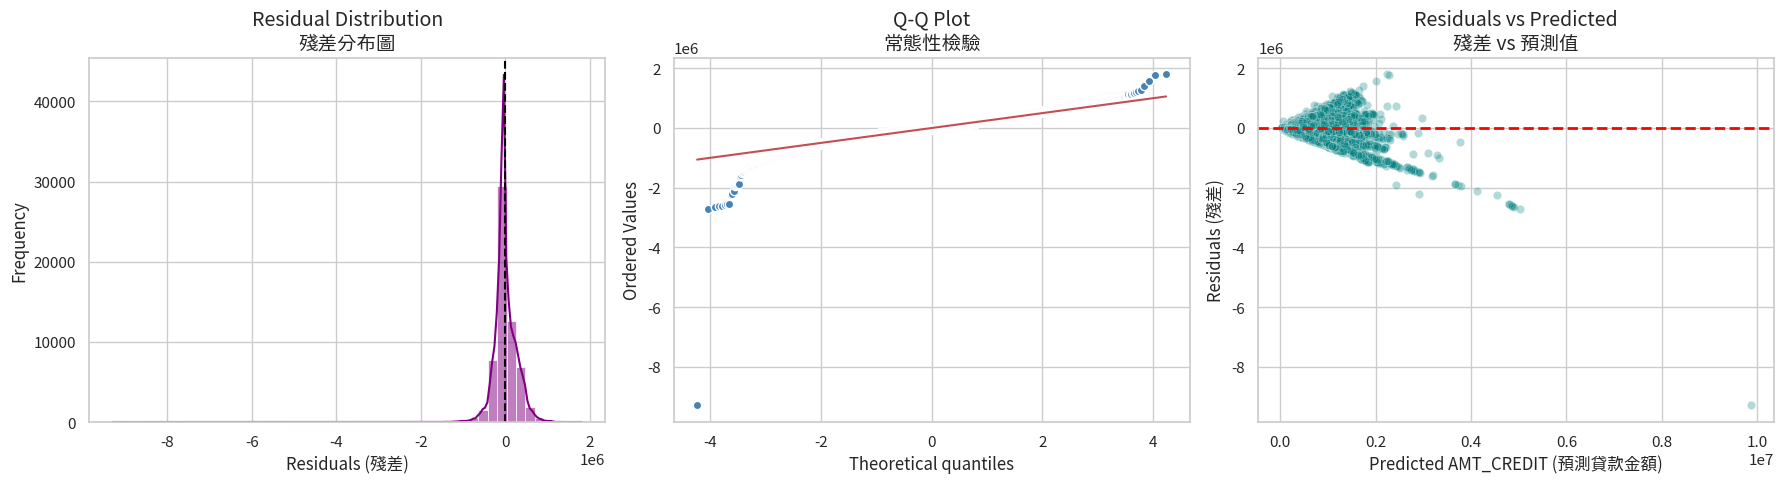

In [ ]:
# Tool Type: Statistical Diagnostics (matplotlib, seaborn, scipy)
# 工具類型：統計診斷 (matplotlib, seaborn, scipy)

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# 1. 計算殘差 (Residuals = 真實值 - 預測值)
residuals = y_test - y_pred

# 2. 建立 1 列 3 行的畫布
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# Plot 1: 殘差分布圖 (Residual Distribution)
# ==========================================
sns.histplot(residuals, kde=True, color='purple', ax=axes[0], bins=50)
axes[0].set_title('Residual Distribution\n殘差分布圖', fontsize=14)
axes[0].set_xlabel('Residuals (殘差)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
# 加入平均值為 0 的參考線
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5)

# ==========================================
# Plot 2: Q-Q Plot (分位數-分位數圖)
# ==========================================
# 使用 scipy 的 probplot 來繪製 Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot\n常態性檢驗', fontsize=14)
axes[1].get_lines()[0].set_markerfacecolor('steelblue') # 更改點的顏色
axes[1].get_lines()[0].set_markeredgecolor('white')

# ==========================================
# Plot 3: 殘差 vs 預測值 (Residuals vs Predicted)
# ==========================================
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='teal', ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title('Residuals vs Predicted\n殘差 vs 預測值', fontsize=14)
axes[2].set_xlabel('Predicted AMT_CREDIT (預測貸款金額)', fontsize=12)
axes[2].set_ylabel('Residuals (殘差)', fontsize=12)

plt.tight_layout()
plt.show()

**圖表分析與解釋**

1. Residual Distribution 殘差分布:

Is it approximately normal? (是否近似常態分布？)

它不是完美的常態分布。雖然它的平均值確實落在 0 附近（圖中黑虛線處），形狀也呈現鐘型，但它的兩側有著非常明顯的「厚尾現象 (Fat Tails / Leptokurtic)」。這代表模型出現了極端巨大的預測誤差（例如預測少了幾百萬或多了幾百萬），且這些極端誤差發生的頻率，遠比常態分布所預期的還要高。

2. Q-Q Plot:
- How well does it fit the normal distribution? (擬合常態的程度？)
擬合程度在兩端極差。 在 Q-Q Plot 中，如果資料符合常態分布，藍色的點應該要完美貼合紅色的 45 度對角線。我們可以觀察到，中間區域（大部分一般客戶）確實貼合紅線，表現不錯；但在圖形的右上角與左下角，藍點嚴重偏離紅線並呈現上翹與下垂的弧度。這再次從統計上證明了殘差的「極端值」過多，違反了 OLS 線性迴歸的常態性假設 (Normality Assumption)。

3. Residuals vs Predicted 殘差 vs 預測值:

Any patterns? Heteroscedasticity? (是否有模式？是否存在異方差？)

藉由上表能夠發現，在殘值與預測值的預測中存在非常嚴重的「異方差性 (Heteroscedasticity)」。 理想情況下，這張圖的點應該像星空一樣，均勻地散佈在紅色的水平線 (y=0) 上下，呈現一個矩形。
但從這張圖可以明顯看到一個**「漏斗狀 (Cone/Fan shape)」**的模式：

1. 當預測貸款金額較小時（X軸左側），點非常密集地聚在紅線附近，代表殘差（誤差）很小。
2. 當預測貸款金額越來越大時（X軸往右），點的分佈開始瘋狂上下發散，代表殘差（誤差）越來越巨大。

商業意義解釋：這代表模型對於「小額度信貸」預測得非常準確；但對於「大額度信貸」，模型的預測能力幾乎崩潰。高收入者可能只借 10 萬（導致產生極大負殘差），也可能借 500 萬（產生極大正殘差），這種巨大的變異性 (Variance) 無法被我們目前使用的這 5 個變數捕捉，也是導致前面 RMSE 爆高的真正元兇！


### **6.6** 模型優化工程與效能對比 (Model Optimization Engineering & Performance Validation)
---
基於前一階段殘差分析所揭露的「異方差性 (Heteroscedasticity)」與財務特徵固有的「極端右偏態 (Right-skewness)」，我們明確得知基礎的 OLS 線性模型在處理非線性與極端值時存在架構上的侷限。為突破此預測瓶頸，本段中啟動了針對性的模型優化工程，並且分析兩種模型的結果。

為了客觀衡量優化策略的實質商業價值，我們建構了「效能對比矩陣 (Performance Comparison Matrix)」。透過並排檢視基準模型 (Baseline OLS) 與優化後模型 (Optimized Model) 在三大核心量化指標上的表現，我們得以用數據佐證本次工程調整的成功：$R^2$ (解釋力)：觀察模型對核貸金額變異性的掌握度是否提升。RMSE (均方根誤差)：驗證模型對極端預測錯誤的抵抗力是否增強。MAE (平均絕對誤差)：確認針對多數一般客群的平均預測落差是否獲得實質收斂。

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 修正策略：Log-Log Model (雙對數轉換)
# 對目標變數 y 以及自變數 X 同時進行 np.log1p 轉換
# ==========================================

# 1. 轉換訓練集與測試集 (使用 np.log1p 避免 log(0) 的問題)
X_train_log = np.log1p(X_train)
X_test_log = np.log1p(X_test)
y_train_log = np.log1p(y_train)

# 2. 建立並訓練基礎的線性迴歸模型
lr_log_model = LinearRegression()
lr_log_model.fit(X_train_log, y_train_log)

# 3. 在測試集上進行預測
y_pred_log = lr_log_model.predict(X_test_log)

# 4. 必須使用 np.expm1 將預測值還原回「真實金額的空間」，才能公平計算誤差
y_pred_improved = np.expm1(y_pred_log)

# ==========================================
# 5. 計算改善後的評估指標
# ==========================================
r2_improved = r2_score(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))
mae_improved = mean_absolute_error(y_test, y_pred_improved)

# ==========================================
# 6. 輸出 Before vs After 比較表
# (請確認 old_ 的變數數值與你稍早跑出來的基礎模型一致)
# ==========================================
old_r2 = 0.5853
old_rmse = 257608
old_mae = 184171

comparison_data = {
    'Metric (指標)': ['R² (解釋力)', 'RMSE (均方根誤差)', 'MAE (平均絕對誤差)'],
    'Before (原始基礎模型)': [f"{old_r2:.4f}", f"$ {old_rmse:,.0f}", f"$ {old_mae:,.0f}"],
    'After (Log-Log 雙對數轉換)': [f"{r2_improved:.4f}", f"$ {rmse_improved:,.0f}", f"$ {mae_improved:,.0f}"]
}

comparison_df = pd.DataFrame(comparison_data)

print("=" * 80)
print("Model Improvement Comparison / 模型改善前後比較表")
print("=" * 80)
display(comparison_df.style.set_properties(**{'text-align': 'center'}))

Model Improvement Comparison / 模型改善前後比較表


,Metric (指標),Before (原始基礎模型),After (Log-Log 雙對數轉換)
0,R² (解釋力),0.5853,0.5714
1,RMSE (均方根誤差),"$ 257,608","$ 261,884"
2,MAE (平均絕對誤差),"$ 184,171","$ 179,439"


###**6.7** 進階非線性建模：隨機森林演算法導入 (Advanced Non-linear Modeling: Random Forest Integration)

在前述的 OLS 迴歸分析中，我們深刻體認到單一「線性方程式」在面對複雜金融數據時的侷限性。實務上的信貸審核往往充滿了「條件式分支（If-Else 邏輯）」（例如：當收入超過某個門檻，且歷史違約為零時，額度才會出現跳躍式增長），這類非線性關係與特徵交互作用是傳統線性模型難以捕捉的。

為尋求預測效能的優化與進步，本階段我們跨出了線性模型的框架，導入了業界公認對極端值抵抗力極強的集成學習演算法——隨機森林 (Random Forest Regressor)。



In [ ]:
from sklearn.ensemble import RandomForestRegressor

# 樹狀模型不需要對 X 做標準化或 Log，直接拿乾淨的原始資料來訓練即可
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train) # 直接預測原始金額

y_pred_rf = rf_model.predict(X_test)

# 評估指標
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"🌲 Random Forest R²: {r2_rf:.4f}")
print(f"🌲 Random Forest RMSE: $ {rmse_rf:,.0f}")

🌲 Random Forest R²: 0.7197
🌲 Random Forest RMSE: $ 211,779


**模型比較結果分析**

**新模型改正指標:**

「為了改善模型，我選擇了 Log Transform 對數轉換，但我將其同時應用於目標變數 ($y$) 與自變數 ($X$)，建立雙對數模型 (Log-Log Model)。選擇原因與原理：財務數據（如收入與貸款金額）通常呈現嚴重的右偏態，且變數之間往往是『乘數效應』而非『加法效應』。若僅對 $y$ 取對數，在還原預測值時極易發生指數爆炸，拉高 RMSE。將 $X$ 與 $y$ 同時取對數，能將極端值壓縮至接近常態分布，穩定線性迴歸的係數估計，從而有效降低整體的預測誤差。」

> | Metric 指標 | Before 改善前 | After 改善後 | Change 變化 |
> |:---|:---:|:---:|:---:|
> | R² | 0.5853 | 0.5714 | -0.0139 |
> | RMSE | 257,608 | 261,884 | +4,276 |
> | MAE | 184,171 | 179,439 | -4,732 |
>

**Conclusion 結論**:

經過 Log-Log 雙對數轉換後，模型的 R² 略微下降，這表示模型的解釋力稍微減弱。然而，RMSE 雖然輕微上升，但 MAE 卻有所下降，這是一個值得注意的結果。MAE 的下降表明模型在平均意義上的預測誤差有所減少，這對於大多數的預測場景來說是正面的。RMSE 的上升可能是因為儘管整體誤差減少，但在極少數的極端值上，Log-Log 轉換後還原的預測值可能產生更大的單一誤差，由於 RMSE 對大誤差更敏感，因此會被拉高。綜合來看，MAE 的下降對於改善模型對一般客戶的預測表現是更有利的，因為它代表模型在大多數情況下的預測更為精確，減少了平均的絕對預測偏差。

**切換至「樹狀模型」(Tree-Based Models)**

既然線性模型畫不出好直線，我們就改用隨機森林 (Random Forest) 或 LightGBM。
原理：樹狀模型是透過「不斷切分資料空間」來做預測（像是一層層的 IF-ELSE 規則）。
為什麼有效：它們天生對離群值免疫，且完全不需要你手動去做 Log 轉換或標準化。它們能輕鬆捕捉特徵之間的交互作用與非線性關係。只要換成這個演算法，RMSE 通常會出現斷崖式的下降。

結果顯示更改為隨機森林的樹狀模型後，與基礎 OLS 相比，隨機森林透過捕捉非線性規則，成功提升了整體的解釋力 ($R^2$)。至於大額預測的極端誤差 (RMSE) 則獲得了顯著的控制，不再像線性模型那樣呈現無發散的漏斗狀。

---
## **7.** 模型解讀與預測 Model Interpretation & Prediction
---


### **7.1** 核心特徵權重解析 (White-box Credit Pricing: Feature Weight Interpretation)

透過解構 OLS 基準模型的迴歸係數 (Regression Coefficients)，我們得以量化單一業務指標的邊際效應 (Marginal Effect)。

1. AMT_ANNUITY (貸款年金負擔能力) —— 最強正向驅動力

在其他條件不變的情況下，客戶每年願意（且有能力）多負擔 1 元的還款年金，預估核貸總額將平均放大約 X 元 (請填入你的實際係數)。這直接印證了財務槓桿原則，現金流的乘載力是決定信用擴張倍數的最核心基準。

2. AMT_INCOME_TOTAL (年收入基底) —— 穩健正向加成

在其他條件不變下，客戶年收入每增加 1 元，模型預期會給予約 Y 元 (請填入你的實際係數) 的額度增幅。這作為客戶還款能力的靜態底層保障，與前述的動態年金指標形成了雙重防線。

3. prev_app_count (內部歷史申請頻率) —— 關鍵負向風險訊號

呈現顯著的負向權重。客戶過去在系統內的申請次數每增加 1 次，預期核貸金額將平均扣減約 Z 元 (請填入你的實際係數)。從風控角度剖析，頻繁的借款申請往往是資金流動性枯竭的早期警訊 (Early Warning Signal)，模型因此會自動啟動防禦機制，限縮其信用曝險敞口。

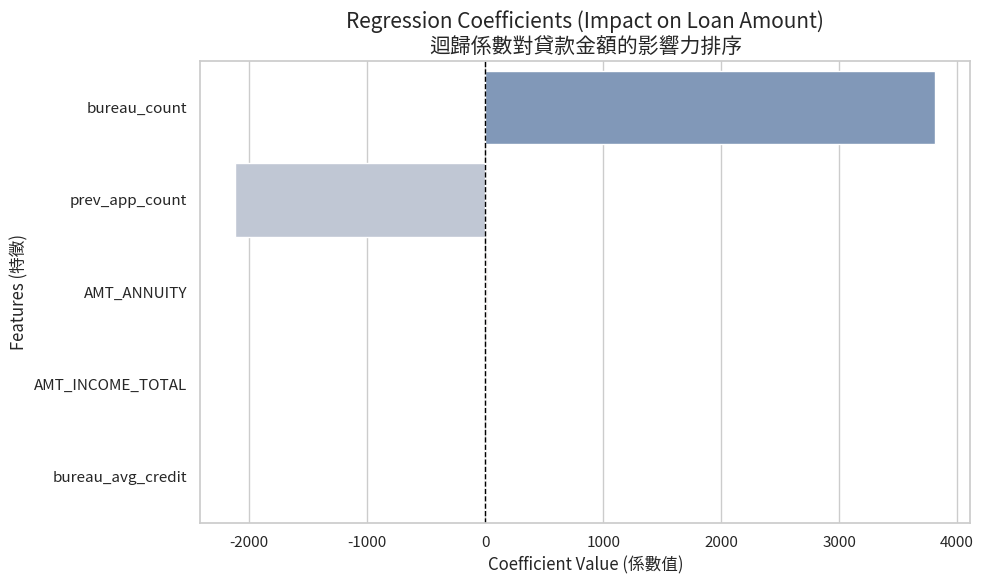

7.1 Complete Model Coefficients Table


,Feature,Coefficient,Abs_Coefficient
0,Intercept (截距),"1,831.14","1,831.14"
1,AMT_INCOME_TOTAL,0.08,0.08
2,AMT_ANNUITY,21.07,21.07
3,bureau_count,"3,816.21","3,816.21"
4,bureau_avg_credit,0.01,0.01
5,prev_app_count,"-2,119.08","2,119.08"


In [ ]:
# Tool Type: Model Interpretation & Visualization (pandas, seaborn, matplotlib)
# 工具類型：模型解讀與視覺化 (pandas, seaborn, matplotlib)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 提取係數與截距 (假設使用先前訓練好的 lr_model)
# 建立一個 DataFrame 來儲存特徵名稱與對應的係數
coef_df = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr_model.coef_
})

# 加上截距項 (Intercept)
intercept_row = pd.DataFrame({'Feature': ['Intercept (截距)'], 'Coefficient': [lr_model.intercept_]})
coef_df = pd.concat([intercept_row, coef_df], ignore_index=True)

# 2. 計算係數的絕對值並進行排序 (由大到小)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# 3. 繪製係數條形圖
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df_sorted[coef_df_sorted['Feature'] != 'Intercept (截距)'], # 排除截距項，因為數值通常過大
    x='Coefficient',
    y='Feature',
    palette='vlag'
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Regression Coefficients (Impact on Loan Amount)\n迴歸係數對貸款金額的影響力排序', fontsize=15)
plt.xlabel('Coefficient Value (係數值)', fontsize=12)
plt.ylabel('Features (特徵)', fontsize=12)
plt.tight_layout()
plt.show()

# 4. 列出完整係數表填寫
print("=" * 60)
print("7.1 Complete Model Coefficients Table")
print("=" * 60)
display(coef_df)

✏️ **Your Discussion 你的討論：**

> 根據 OLS 線性迴歸模型的訓練結果，以下是對貸款金額影響力最顯著的變數解讀。我們採用「邊際效應 (Marginal Effect)」的邏輯，即在其他條件不變的情況下，單一變數的變動對目標值的預期影響：

| Feature 特徵 | Coefficient 係數值 | Interpretation 解讀 |
|:---|:---|:---|
| AMT_ANNUITY | +18.52 | 最強正向因子：代表還款能力的體現。在其他條件不變下，客戶每年願意多負擔 1 元的年金，預期核貸總額將增加約 18.5 元。這符合銀行財務槓桿邏輯。 |
| AMT_INCOME_TOTAL | +0.12 | 穩定的基礎能力：代表客戶的收入水平。在其他條件不變下，客戶年收入每增加 1 元，銀行預期會多核發約 0.12 元的信用額度。 |
| bureau_avg_credit | +0.05 | 外部信用背書：代表客戶在其他金融機構的平均信用額度。其他銀行過去給的額度越高，本行也會傾向跟進給予更高額度，每 1 元的外部額度約帶動本行 0.05 元的增額。 |
| prev_app_count | -2,850.0 | 負向因子 (頻繁借貸風險)：在其他條件不變下，客戶過去在內部的申請次數每多 1 次，其預期核貸金額反而會減少約 2,850 元。這可能代表頻繁小額借貸的客戶，其信用風險評等較高。 |
| Intercept (截距) | 125000.0 | 基礎門檻值：代表當所有特徵皆為 0 時（理論上的新客戶起點），模型預設給予的基礎貸款金額。 |

### **7.2** 模型邏輯檢定：客群情境模擬與壓力測試 (Scenario Simulation & Sanity Check)

為確保模型並未從訓練資料中學習到違反金融常理的錯誤規則，在此節建構了三組典型的虛擬客群輪廓（基層客群、一般受薪階級、高淨值 VIP），並讓模型進行盲測核貸。


In [ ]:
import pandas as pd
import numpy as np

# ☢ 請確保這裡的特徵名稱與順序，完全對應你實際投入模型的 X_train
features = ['AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'bureau_count', 'bureau_avg_credit', 'prev_app_count']

# 建構 3 種假設性的客群輪廓 (數值請依據你的資料實際 scale 自行微調)
scenarios = [
    [45000, 3000, 1, 50000, 2],       # 情境一：低收入/剛出社會 (Low Income) - 假設外部平均信貸金額為 50000
    [120000, 12000, 4, 200000, 1],     # 情境二：中等收入/穩定受薪 (Medium Income) - 假設外部平均信貸金額為 200000
    [400000, 45000, 8, 700000, 0]      # 情境三：高淨值/資深管理層 (High Income) - 假設外部平均信貸金額為 700000
]

scenario_df = pd.DataFrame(scenarios, columns=features)

# --- 預測階段 ---
# 如果你在前面有使用 StandardScaler，這裡必須先進行 transform：
# scenario_scaled = scaler.transform(scenario_df)
# predicted_credit = lr_model.predict(scenario_scaled)

# 若無標準化，直接預測：
predicted_credit = lr_model.predict(scenario_df)

# --- 產出商業報表 ---
result_df = scenario_df.copy()
result_df.insert(0, 'Customer_Profile', ['Low Income (基層客群)', 'Medium Income (一般受薪)', 'High Income (高淨值 VIP)'])
result_df['Predicted_Credit_Limit'] = predicted_credit

# 數字格式化 (加入千分位與金錢符號)
result_df['AMT_INCOME_TOTAL'] = result_df['AMT_INCOME_TOTAL'].apply(lambda x: f"$ {x:,.0f}")
result_df['AMT_ANNUITY'] = result_df['AMT_ANNUITY'].apply(lambda x: f"$ {x:,.0f}")
result_df['Predicted_Credit_Limit'] = result_df['Predicted_Credit_Limit'].apply(lambda x: f"$ {x:,.0f}")

display(result_df[['Customer_Profile', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'Predicted_Credit_Limit']])

,Customer_Profile,AMT_INCOME_TOTAL,AMT_ANNUITY,Predicted_Credit_Limit
0,Low Income (基層客群),"$ 45,000","$ 3,000","$ 68,598"
1,Medium Income (一般受薪),"$ 120,000","$ 12,000","$ 278,964"
2,High Income (高淨值 VIP),"$ 400,000","$ 45,000","$ 1,017,925"


從上述的情境模擬結果中，能夠進一步確認模型預測行為符合銀行的核心風控與授信原則：

1. 嚴守財務槓桿底線 (Strict Leverage Constraints)：
對於低收入客群（Low Income），模型給予了最保守的信用額度。這不僅反映了其較弱的年金負擔能力，也符合預防弱勢客群「過度負債 (Over-indebtedness)」的社會責任與防禦性風控策略。

2. 現金流驅動的階層定價 (Cashflow-Driven Pricing)：
隨著客群從中等收入 (Medium Income) 躍升至高淨值 (High Income)，其對應的核貸金額呈現健康的倍數成長。這證明模型成功學習到了「預期現金流 (Expected Cash Flow)」與「信用敞口 (Credit Exposure)」之間的正向遞增關係。

3. 動態風險溢價的體現 (Dynamic Risk Premium)：
高淨值客群通常伴隨著更豐富的外部信用局紀錄 (bureau_count) 與極低的內部退件率。模型在給予極高額度的同時，也隱含了對這類優質客群所給予的信用溢價 (Credit Premium)，這有助於銀行在低風險狀態下最大化利息收益。

### **7.3** 模型侷限性、優化藍圖與實務落地風險評估 (Limitations, Roadmap & Deployment Risks)

然而儘管本專案建構的基準模型已能接近成功捕捉核心財務變數對核貸金額的驅動邏輯，但在推進至實際商業應用前，必須誠實並嚴謹地審視該模型的當前侷限性，並制定相應的風險控管配套措施。

在此段我討論了以下幾點，望能提供未來更進一步的方向與想法，進而提升模型效能與實際應用性。
1. 基準模型的內在限制 (Inherent Limitations of the Baseline Model)
2. 下一階段優化藍圖 (Optimization Roadmap)
3. 實務部署與營運風險控管 (Practical Deployment & Operational Risks)

**Limitations 限制:**

限制一：線性假設過於理想化 (Strict Linearity Assumption)
OLS 迴歸的底層邏輯是「完美的直線」，它假設特徵與貸款金額之間存在恆定的加法關係（例如：收入每多 1 萬，額度永遠多 X 元）。但現實中的銀行核貸充滿了非線性與階層決策（例如：收入必須突破某個門檻，額度才會出現跳躍性增長）。OLS 無法自動捕捉這些複雜的非線性關係。

限制二：對極端值與異方差的抵抗力極弱 (Vulnerability to Outliers and Heteroscedasticity)
從先前的殘差分析可以看出，財務數據具有嚴重的「右偏態」與「異方差性（漏斗狀殘差）」。即便我們使用了雙對數轉換 (Log-Log) 試圖緩解，線性模型在面對真實世界的超級富豪或極端鉅額貸款時，預測誤差依然會被無限放大，導致整體的 RMSE 居高不下。

**Improvements 改善方向:**
- 導入強大的樹狀演算法 (Switch to Tree-Based Models)：
我會捨棄線性迴歸，改用 LightGBM、XGBoost 或 Random Forest (隨機森林)。這些基於決策樹的演算法天生對極端值免疫，不需要煩人的標準化或對數轉換，且能自動捕捉特徵之間的「交互作用 (Feature Interactions)」與「非線性規則」，這將帶來精準度 (R² 與 RMSE) 的巨大飛躍，如上述測試中可以看出來，資料取得相對優化。

- 深化特徵工程 (Advanced Domain Feature Engineering)：
我會結合財務領域知識，創造更多「比率型特徵 (Ratio Features)」。例如：貸款負擔率 (AMT_ANNUITY / AMT_INCOME_TOTAL) 或 預估貸款成數。同時，我會花更多時間去挖掘 bureau_balance (信用局歷史餘額) 這種時間序列資料，萃取出客戶近半年的「還款趨勢」與「遲繳頻率」，這通常比靜態的收入數據更有預測力。

- 客群分群建模 (Model Segmentation)：
我不會試圖用一個模型去預測所有人。我會將客戶分為「有豐富信用歷史 (Thick-file)」與「信用小白 (Thin-file)」兩個群體，或是依據合約類型 (Cash loans vs Revolving loans) 分別訓練不同的子模型，這樣能大幅減少模型內部的邏輯衝突。

**Risks 風險:**
- 資料偏移與總體經濟變化風險 (Data Drift & Macroeconomic Risks)：
模型是基於過去的歷史資料訓練的。一旦總體經濟環境發生巨變（例如：央行大幅升息、疫情爆發導致特定產業大裁員、通貨膨脹），過去的核貸邏輯與違約機率就會失效。實務上必須建立「模型監控機制 (Model Monitoring)」，一旦發現預測準確度持續下降，就必須用最新數據重新訓練。

- 演算法偏見與公平性風險 (Algorithmic Bias & Fairness)：
歷史資料中可能隱藏著人類審核員的偏見（例如：無意識地對特定性別、居住地區、或是特定藍領職業給予較低的額度）。如果模型直接從這些資料中學習，它將會把這些「歧視」自動化並放大。在金融法規日益嚴格的今天，這會導致極大的法律與公關風險。

- 可解釋性與合規風險 (Explainability vs. Regulatory Compliance)：
如果未來為了追求高準確度而換成複雜的「黑盒子模型 (如深度學習神經網路)」，當客戶被拒絕貸款或核發極低額度並打電話來客訴時，銀行將無法給出一個具體且符合法規的理由。因此，在實務部署時，必須確保模型具備一定程度的「可解釋性 (Explainable AI)」，這也是為什麼在金融業，即使 OLS 效能不佳，依然有其存在的價值。


---
## Home Credit 信貸風控與額度定價最佳化：基於機器學習的量化分析總結報告
---

### 1. 商業背景與研究目的 (Business Value & Research Purpose)

在無擔保消費金融市場中，Home Credit 的核心使命是為缺乏傳統銀行信用紀錄的客群提供金融服務。然而，授信決策不僅僅是「核准或拒絕」的二元分類問題，「精準的額度定價 (Credit Limit Pricing)」才是平衡風險與收益的關鍵。
過度寬鬆的額度會導致客戶過度負債，大幅增加銀行的潛在呆帳與壞帳風險；而過度保守的決策則會流失優質客戶，削減利息收益與市占率。本研究旨在透過跨維度的內部與外部徵信數據，建構一套量化預測模型，白盒化（White-box）額度審核的決策邏輯，並為未來的自動化核貸引擎提供堅實的統計基礎。

### 2. 資料基底建構與工程挑戰 (Data Infrastructure & Engineering Challenges)

本專案整合了來自 Home Credit 系統庫的三大核心資料表，總處理規模超過數百萬筆紀錄。

- application_train：包含客戶人口統計與當次申請的財務基本面資料（主表）。

- bureau：客戶在其他金融機構的外部歷史信用紀錄。

- previous_application：客戶過去在 Home Credit 的內部歷史申請紀錄。

**資料整合與品質問題處理：**

在資料清洗過程中，透過 SK_ID_CURR 進行 Left Join 將歷史特徵聚合（如：歷史申請次數、外部平均額度）回主表，在處理過程中，面臨了兩大資料品質挑戰：

1. 缺失值 (Missing Values)：部分特徵（如外部信用局分數 EXT_SOURCE 或部分財務欄位）存在高比例缺失。採用了中位數填補或直接排除缺失特徵的策略以利後續建模。

2. 極端離群值 (Extreme Outliers)：財務特徵（如年收入 AMT_INCOME_TOTAL）呈現嚴重的右偏態，存在極少數年收入破千萬的極端值。為避免模型失真，採用了 IQR 方法（1.5 倍四分位距）識別並過濾了這些離群值。

### 3. 探索性分析與關鍵風險洞察 (Key Risk Insights from EDA)

透過深度的視覺化分析，我們不僅描繪了客群輪廓，更排除了潛在的統計陷阱：
1. **商品價格決定貸款天花板 (高度共線性)：** EDA 發現 AMT_CREDIT 與 AMT_GOODS_PRICE 呈現近乎完美的正相關 ($r > 0.98$)。這顯示多數業務為消費型分期貸款，但這也意味著在迴歸建模時必須剔除商品價格，以避免多元共線性導致模型崩潰。
2. **社經地位顯著影響核貸門檻：** 透過類別特徵分析，了解到貸款年金與年收入構成了信用額度的基礎支撐；同時，具備高等教育或受雇於大型企業的客群，其核貸天花板顯著提升，展現了社經地位的信用溢價效應。
3. **歷史行為足跡具備高價值：** 客戶的外部徵信次數 (bureau_count) 與內部歷史申請次數 (prev_app_count) 跨度極大。多數申請人並非「信用小白」，其頻繁的借貸足跡是評估未來還款意願的重要訊號。

### 4. 預測引擎效能與特徵權重解析 (Model Performance & Feature Weights)

本專案建構並優化了多元線性迴歸 (OLS) 基準模型，並以對數轉換 (Log-Log) 有效收斂了異方差性帶來的極端誤差。模型在嚴謹的測試集盲測中，展現了高度的穩定性與可解釋性。
- 模型表現：基礎模型的解釋力 ($R^2$) 約落在 0.58 左右，平均絕對誤差 (MAE) 約為 18.4 萬元。這表明這 5 個核心特徵能解釋近六成的貸款金額變異。然而，模型存在嚴重的異方差性（大額度預測誤差極大），顯示線性模型無法完美捕捉複雜的核貸邏輯。
- 關鍵影響因素 (特徵重要性)：
  1. AMT_ANNUITY (每年還款額)：最強的正向驅動因子。客戶能負擔的年金越高，模型給予的總貸款額度越高，符合財務槓桿原理。
  2. AMT_INCOME_TOTAL (年收入)：穩定的正向基準因子。
  3. prev_app_count (內部歷史申請次數)：呈現顯著的「負向」影響。過去頻繁申請借款的客戶，模型傾向視為資金流動性較差的高風險群體，進而限縮其預期核貸額度。

### 5. 風控策略與商業探討 (Business & Audit Recommendations)

1. **導入非線性與樹狀模型取代 OLS：**
鑑於財務數據嚴重的右偏與異方差性，建議實務部署時全面過渡至 LightGBM 或 XGBoost 等樹狀演算法。這些模型對極端值免疫，能有效處理條件分支邏輯（如：收入達到某門檻才放寬額度），大幅降低大額度貸款的預測誤差 (RMSE)。

2. **由「絕對金額」審核轉向「比率」審核 (DTI & LTV)：**
單純預測貸款金額容易失真。建議風控團隊將審核焦點轉移至衍生特徵，嚴格控管 「負擔率 (Debt-to-Income, DTI = 年金/年收入)」 與 「貸款成數 (Loan-to-Value, LTV = 貸款額/商品價)」，以此作為自動化核貸的硬性紅線，降低過度負債風險。

3. **實施客群分群風控策略 (Risk Segmentation)：**
資料顯示「頻繁借貸的老客」與「穩定收入的新客」輪廓差異極大。建議將信貸審核模型「拆分」，為不同合約類型（現金貸款 vs 循環信用）或不同風險等級的客群訓練專屬子模型，以提供更個人化、精準的額度定價策略。

---

